# 🧠 Task 3 — Knowledge Distillation (KD)

Course: Model Compression Techniques — VGG-based KD on CIFAR-100.

**Using the repositories:**

1. RepDistiller: https://github.com/HobbitLong/RepDistiller

2. Knowledge-Distillation-Zoo: https://github.com/AberHu/Knowledge-Distillation-Zoo

## 0. Setup

### Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### 📁 Dataset Preparation (CIFAR-100)

In [3]:
# ==================== DATA PREPARATION ====================
print("Loading CIFAR-100 dataset...")

# Data transforms
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

# Load datasets
trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

# Create validation split from training set
train_size = int(0.9 * len(trainset))
val_size = len(trainset) - train_size
trainset, valset = torch.utils.data.random_split(trainset, [train_size, val_size])

# Data loaders
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
valloader = DataLoader(valset, batch_size=100, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

print(f"Train size: {len(trainset)}, Val size: {len(valset)}, Test size: {len(testset)}")

Loading CIFAR-100 dataset...


100%|██████████| 169M/169M [00:08<00:00, 20.4MB/s] 


Train size: 45000, Val size: 5000, Test size: 10000


## 1. Logit Matching (LM)

### setup

In [6]:
# ==================== DISTILLATION LOSS FUNCTIONS ====================

class BasicLogitMatchingLoss(nn.Module):
    """Standard Knowledge Distillation with temperature scaling"""
    def __init__(self, temperature=4.0, alpha=0.9):
        super().__init__()
        self.temperature = temperature
        self.alpha = alpha
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, student_logits, teacher_logits, labels):
        # Soft loss: KL divergence between teacher and student
        soft_loss = F.kl_div(
            F.log_softmax(student_logits / self.temperature, dim=1),
            F.softmax(teacher_logits / self.temperature, dim=1),
            reduction='batchmean'
        ) * (self.temperature ** 2)

        # Hard loss: standard cross-entropy
        hard_loss = self.ce_loss(student_logits, labels)

        # Combined loss
        return self.alpha * soft_loss + (1 - self.alpha) * hard_loss

class LabelSmoothingLoss(nn.Module):
    """Label Smoothing as described in "Rethinking the Inception Architecture" """
    def __init__(self, num_classes=100, smoothing=0.1):
        super().__init__()
        self.num_classes = num_classes
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing

    def forward(self, pred, target):
        pred = pred.log_softmax(dim=-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.num_classes - 1))
            true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        return torch.mean(torch.sum(-true_dist * pred, dim=-1))

class DecoupledKDLoss(nn.Module):
    """Decoupled Knowledge Distillation Loss"""
    def __init__(self, temperature=4.0, alpha=1.0, beta=1.0):
        super().__init__()
        self.temperature = temperature
        self.alpha = alpha
        self.beta = beta
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, student_logits, teacher_logits, labels):
        # Target class distillation (TCKD)
        target_mask = torch.zeros_like(student_logits).scatter_(1, labels.unsqueeze(1), 1).bool()

        # Non-target class distillation (NCKD)
        student_soft = F.softmax(student_logits / self.temperature, dim=1)
        teacher_soft = F.softmax(teacher_logits / self.temperature, dim=1)

        # TCKD: focus on target class
        tckd_loss = F.binary_cross_entropy(
            student_soft[target_mask],
            teacher_soft[target_mask]
        )

        # NCKD: focus on non-target classes
        nckd_loss = F.kl_div(
            F.log_softmax(student_logits[~target_mask].view(student_logits.size(0), -1) / self.temperature, dim=1),
            F.softmax(teacher_logits[~target_mask].view(teacher_logits.size(0), -1) / self.temperature, dim=1),
            reduction='batchmean'
        ) * (self.temperature ** 2)

        # Hard label loss
        hard_loss = self.ce_loss(student_logits, labels)

        return self.alpha * tckd_loss + self.beta * nckd_loss + hard_loss

In [7]:
# ==================== TRAINING FUNCTIONS ====================
def train_student(model, teacher_model, trainloader, valloader, criterion, optimizer, epochs=100, device='cuda', model_name='student'):
    """Generic training function for student models"""
    teacher_model.eval()
    best_val_acc = 0.0
    train_losses = []
    val_accs = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        pbar = tqdm(trainloader, desc=f'Epoch {epoch+1}/{epochs}')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            # Get student outputs
            student_outputs = model(inputs)

            # Get teacher outputs
            with torch.no_grad():
                teacher_outputs = teacher_model(inputs)

            # Compute loss
            if isinstance(criterion, LabelSmoothingLoss):
                loss = criterion(student_outputs, labels)
            else:
                loss = criterion(student_outputs, teacher_outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})

        # Validation
        val_acc = evaluate(model, valloader, device)
        train_losses.append(running_loss / len(trainloader))
        val_accs.append(val_acc)

        print(f'Epoch {epoch+1}: Train Loss: {running_loss/len(trainloader):.4f}, Val Acc: {val_acc:.2f}%')

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'{model_name}_best.pth')

    return train_losses, val_accs

def evaluate(model, dataloader, device):
    """Evaluate model accuracy"""
    model.eval()
    correct = 0
    total = 0

    pbar = tqdm(dataloader)
    with torch.no_grad():
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return 100. * correct / total

### training

In [87]:
# ==================== TRAIN OR LOAD TEACHER ====================
print("\n" + "="*50)
print("LOADING/TRAINING VGG-16 TEACHER MODEL")
print("="*50)

# from torchvision import models

# Load pretrained VGG-16 model from torchvision
teacher = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_vgg16_bn", pretrained=True).to(device).eval()
teacher_acc = evaluate(teacher, testloader, device)
print(f"Teacher (VGG-16) Test Accuracy: {teacher_acc:.2f}%")

Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
100%|██████████| 10000/10000 [00:36<00:00, 275.61it/s]

Teacher (VGG-16) Test Accuracy: 74.00%


In [10]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

In [12]:
# ==================== TRAIN STUDENTS WITH DIFFERENT METHODS ====================
# 1. Basic Logit Matching
from torchvision import models

print("\n" + "="*50)
print("TRAINING STUDENT WITH BASIC LOGIT MATCHING")
print("="*50)

student_lm = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_vgg11_bn", pretrained=False).to(device)
criterion_lm = BasicLogitMatchingLoss(temperature=4.0, alpha=0.9)
optimizer_lm = optim.SGD(student_lm.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler_lm = optim.lr_scheduler.MultiStepLR(optimizer_lm, milestones=[60, 120, 160], gamma=0.2)
train_losses_lm, val_accs_lm = train_student(student_lm, teacher, trainloader, valloader, criterion_lm, optimizer_lm, epochs=50, device=device, model_name='student_lm')

Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master



TRAINING STUDENT WITH BASIC LOGIT MATCHING


100%|██████████| 50/50 [00:01<00:00, 40.30it/s]


Epoch 1: Train Loss: 19.2973, Val Acc: 4.22%


100%|██████████| 50/50 [00:01<00:00, 42.75it/s]


...

Epoch 48: Train Loss: 3.0068, Val Acc: 60.70%


100%|██████████| 50/50 [00:01<00:00, 42.29it/s]


Epoch 49: Train Loss: 2.9075, Val Acc: 60.90%


100%|██████████| 50/50 [00:01<00:00, 40.43it/s]

Epoch 50: Train Loss: 2.9021, Val Acc: 61.06%


In [13]:
# 2. Label Smoothing
print("\n" + "="*50)
print("TRAINING STUDENT WITH LABEL SMOOTHING")
print("="*50)

# student_ls = VGG('VGG11', num_classes=100).to(device)
# student_ls = make_vgg11_cifar100().to(device)
student_ls = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_vgg11_bn", pretrained=False).to(device)
criterion_ls = LabelSmoothingLoss(num_classes=100, smoothing=0.1)
optimizer_ls = optim.SGD(student_ls.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler_ls = optim.lr_scheduler.MultiStepLR(optimizer_ls, milestones=[60, 120, 160], gamma=0.2)

# Note: Label smoothing doesn't use teacher, but we pass it for API consistency
train_losses_ls, val_accs_ls = train_student(student_ls, teacher, trainloader, valloader, criterion_ls, optimizer_ls, epochs=50, device=device, model_name='student_ls')


TRAINING STUDENT WITH LABEL SMOOTHING


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
100%|██████████| 50/50 [00:01<00:00, 42.21it/s]


Epoch 1: Train Loss: 4.5756, Val Acc: 3.32%


100%|██████████| 50/50 [00:01<00:00, 43.96it/s]


Epoch 2: Train Loss: 4.2997, Val Acc: 6.12%


...

Epoch 48: Train Loss: 1.5187, Val Acc: 57.90%


100%|██████████| 50/50 [00:01<00:00, 42.21it/s]


Epoch 49: Train Loss: 1.4966, Val Acc: 58.10%


100%|██████████| 50/50 [00:01<00:00, 41.25it/s]

Epoch 50: Train Loss: 1.4787, Val Acc: 57.66%


In [16]:
# 3. Decoupled KD
print("\n" + "="*50)
print("TRAINING STUDENT WITH DECOUPLED KD")
print("="*50)

student_dkd = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_vgg11_bn", pretrained=False).to(device)
criterion_dkd = DecoupledKDLoss(temperature=4.0, alpha=1.0, beta=8.0)
optimizer_dkd = optim.SGD(student_dkd.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler_dkd = optim.lr_scheduler.MultiStepLR(optimizer_dkd, milestones=[60, 120, 160], gamma=0.2)
train_losses_dkd, val_accs_dkd = train_student(student_dkd, teacher, trainloader, valloader, criterion_dkd, optimizer_dkd, epochs=50, device=device, model_name='student_dkd')


TRAINING STUDENT WITH DECOUPLED KD


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
100%|██████████| 50/50 [00:01<00:00, 41.88it/s]


Epoch 1: Train Loss: 49.4692, Val Acc: 5.10%


100%|██████████| 50/50 [00:01<00:00, 42.28it/s]


Epoch 2: Train Loss: 45.7840, Val Acc: 9.68%


...

Epoch 48: Train Loss: 14.6957, Val Acc: 60.26%


100%|██████████| 50/50 [00:01<00:00, 44.80it/s]


Epoch 49: Train Loss: 14.5226, Val Acc: 60.58%


100%|██████████| 50/50 [00:01<00:00, 43.97it/s]


Epoch 50: Train Loss: 14.5460, Val Acc: 61.46%


### evaluation

In [17]:
# ==================== EVALUATION ====================
print("\n" + "="*50)
print("FINAL EVALUATION ON TEST SET")
print("="*50)

# Load best models
student_lm.load_state_dict(torch.load('student_lm_best.pth'))
student_ls.load_state_dict(torch.load('student_ls_best.pth'))
student_dkd.load_state_dict(torch.load('student_dkd_best.pth'))

lm_acc = evaluate(student_lm, testloader, device)
ls_acc = evaluate(student_ls, testloader, device)
dkd_acc = evaluate(student_dkd, testloader, device)

print(f"\nBasic Logit Matching Test Accuracy: {lm_acc:.2f}%")
print(f"Label Smoothing Test Accuracy: {ls_acc:.2f}%")
print(f"Decoupled KD Test Accuracy: {dkd_acc:.2f}%")


FINAL EVALUATION ON TEST SET


100%|██████████| 100/100 [00:01<00:00, 58.99it/s]


Basic Logit Matching Test Accuracy: 62.96%
Label Smoothing Test Accuracy: 60.76%
Decoupled KD Test Accuracy: 62.52%


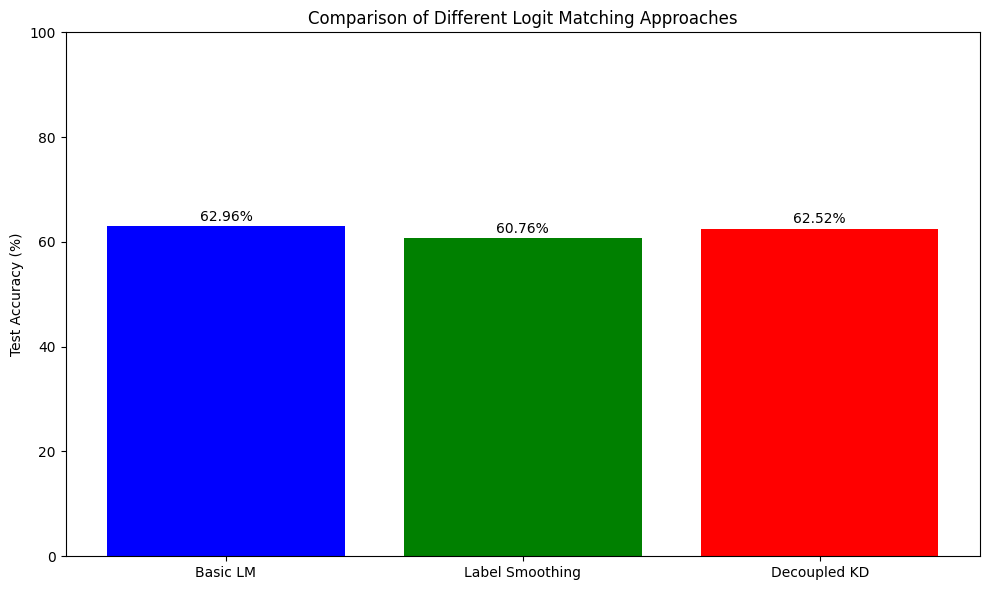


Analysis saved to task3_1_comparison.png


In [18]:
# Visualization
methods = ['Basic LM', 'Label Smoothing', 'Decoupled KD']
accuracies = [lm_acc, ls_acc, dkd_acc]

plt.figure(figsize=(10, 6))
plt.bar(methods, accuracies, color=['blue', 'green', 'red'])
plt.ylabel('Test Accuracy (%)')
plt.title('Comparison of Different Logit Matching Approaches')
plt.ylim([0, 100])
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.savefig('task3_1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAnalysis saved to task3_1_comparison.png")

## 2. SoTA KD methods comparison

### setup

In [35]:
# ==================== ADDITIONAL LOSS FUNCTIONS ====================
class HintLoss(nn.Module):
    """Hint-based Knowledge Distillation (FitNets)"""
    def __init__(self, alpha=1.0):
        super().__init__()
        self.alpha = alpha
        self.ce_loss = nn.CrossEntropyLoss()
        self.mse_loss = nn.MSELoss()

    def forward(self, student_logits, teacher_logits, student_hint, teacher_hint, labels):
        # Feature matching loss
        hint_loss = self.mse_loss(student_hint, teacher_hint)

        # Classification loss
        ce_loss = self.ce_loss(student_logits, labels)

        return ce_loss + self.alpha * hint_loss

class ContrastiveLoss(nn.Module):
    """Numerically stable CRD-like loss (InfoNCE-style with multiple positives)"""
    def __init__(self, temperature=0.07, eps=1e-8):
        super().__init__()
        self.temperature = temperature
        self.eps = eps

    def forward(self, s_feats, t_feats, labels):
        """
        s_feats: (B, D) student projected feats (float)
        t_feats: (B, D) teacher projected feats (float), should be detached
        labels:  (B,) long
        """
        device = s_feats.device
        B = s_feats.size(0)

        # normalize
        s = F.normalize(s_feats, dim=1)
        t = F.normalize(t_feats, dim=1)

        # similarity matrix (B x B)
        logits = torch.matmul(s, t.t()) / self.temperature  # student vs teacher
        # For stability subtract row-wise max
        logits_max, _ = torch.max(logits, dim=1, keepdim=True)
        logits = logits - logits_max.detach()

        # mask for positives (same class)
        labels = labels.view(-1,1)
        positives = (labels == labels.t()).float().to(device)
        # exclude self-pair if teacher==student index same image is a positive; that's OK in CRD,
        # but typical practice excludes diagonal as they are trivially max; we'll exclude diag:
        diag = torch.eye(B, device=device)
        positives = positives * (1.0 - diag)

        # compute logsoftmax over teacher dimension
        exp_logits = torch.exp(logits)  # already stabilized by subtraction
        denom = exp_logits.sum(dim=1, keepdim=True) + self.eps  # (B,1)
        log_prob = logits - torch.log(denom)  # log softmax

        # For each anchor, get mean log_prob over positive indices
        positive_sum = (positives * log_prob).sum(dim=1)  # sum over positives
        positive_count = positives.sum(dim=1)  # number of positives per anchor

        # Avoid division by zero: only keep anchors with at least one positive
        mask_nonzero = (positive_count > 0).float()
        # safe mean
        mean_log_prob_pos = torch.where(
            mask_nonzero.bool(),
            positive_sum / (positive_count + self.eps),
            torch.zeros_like(positive_sum)
        )

        # loss is negative mean over anchors that have positives
        valid_count = mask_nonzero.sum().clamp(min=1.0)
        loss = - mean_log_prob_pos.sum() / valid_count

        return loss

In [27]:

class VGGHintWrapper(nn.Module):
    """Wrapper around repo VGG model to extract intermediate features for Hints"""
    def __init__(self, base_model):
        super().__init__()
        self.model = base_model
        self.hint_feature = None
        
        # Register hook to capture intermediate features
        # For VGG, we'll hook into the features module at a middle layer
        self._register_hook()
    
    def _register_hook(self):
        # Hook into the middle of the feature extractor
        # For VGG11, this is typically after the 3rd or 4th pooling layer
        def hook_fn(module, input, output):
            self.hint_feature = output
        
        # Find a good layer to hook (e.g., after adaptive pooling or middle conv block)
        # For VGG models, target the layer before classifier
        if hasattr(self.model, 'features'):
            # Hook to the last layer of features
            self.model.features[-1].register_forward_hook(hook_fn)
        elif hasattr(self.model, 'avgpool'):
            self.model.avgpool.register_forward_hook(hook_fn)
    
    def forward(self, x, return_features=False):
        logits = self.model(x)
        
        if return_features:
            # Flatten the hint feature
            hint = self.hint_feature.view(self.hint_feature.size(0), -1)
            return logits, hint
        return logits

# ==================== WRAPPER FOR CRD ====================

class VGGCRDWrapper(nn.Module):
    """Wrapper around repo VGG model to add projection head for CRD"""
    def __init__(self, base_model, feat_dim=128):
        super().__init__()
        self.model = base_model
        self.pooled_feature = None
        
        # Add projection head for contrastive learning
        self.projection = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(True),
            nn.Linear(512, feat_dim)
        )
        
        self._register_hook()
    
    def _register_hook(self):
        # Hook to capture pooled features before classifier
        def hook_fn(module, input, output):
            self.pooled_feature = output
        
        # Hook the last layer of features or avgpool
        if hasattr(self.model, 'avgpool'):
            self.model.avgpool.register_forward_hook(hook_fn)
        elif hasattr(self.model, 'features'):
            self.model.features[-1].register_forward_hook(hook_fn)
    
    def forward(self, x, return_features=False):
        logits = self.model(x)
        
        if return_features:
            # Get pooled features and project them
            pooled = self.pooled_feature.view(self.pooled_feature.size(0), -1)
            proj_feats = self.projection(pooled)
            return logits, proj_feats
        return logits

### training

In [37]:
# ==================== TRAINING FUNCTIONS FOR DIFFERENT METHODS ====================
def train_hint_student(student, teacher, trainloader, valloader, epochs=200, device='cuda'):
    """Train student with Hint-based distillation"""
    teacher.eval()
    criterion = HintLoss(alpha=100.0)
    optimizer = optim.SGD(student.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[60, 120, 160], gamma=0.2)

    best_val_acc = 0.0

    for epoch in range(epochs):
        student.train()
        running_loss = 0.0

        pbar = tqdm(trainloader, desc=f'Hint Epoch {epoch+1}/{epochs}')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            # Get outputs with features
            student_logits, student_hint = student(inputs, return_features=True)
            with torch.no_grad():
                teacher_logits, teacher_hint = teacher(inputs, return_features=True)

            loss = criterion(student_logits, teacher_logits, student_hint, teacher_hint, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})

        scheduler.step()

        # Validation
        if (epoch + 1) % 10 == 0:
            val_acc = evaluate_model(student, valloader, device)
            print(f'Epoch {epoch+1}: Loss: {running_loss/len(trainloader):.4f}, Val Acc: {val_acc:.2f}%')

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(student.state_dict(), 'student_hint_best.pth')

    return student

def train_crd_student(student, teacher, trainloader, valloader, epochs=200, device='cuda'):
    """Train student with Contrastive Representation Distillation"""
    teacher.eval()
    # contrastive_criterion = ContrastiveLoss(temperature=0.07, alpha=1.0, beta=0.8)
    contrastive_criterion = ContrastiveLoss(temperature=0.07)
    ce_criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(student.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[60, 120, 160], gamma=0.2)

    best_val_acc = 0.0

    for epoch in range(epochs):
        student.train()
        running_loss = 0.0

        pbar = tqdm(trainloader, desc=f'CRD Epoch {epoch+1}/{epochs}')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            # Get outputs with features
            student_logits, student_feats = student(inputs, return_features=True)
            with torch.no_grad():
                teacher_logits, teacher_feats = teacher(inputs, return_features=True)

            # Combined loss
            ce_loss = ce_criterion(student_logits, labels)
            crd_loss = contrastive_criterion(student_feats, teacher_feats, labels)
            loss = ce_loss + 0.8 * crd_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})

        scheduler.step()

        # Validation
        if (epoch + 1) % 10 == 0:
            val_acc = evaluate_model(student, valloader, device)
            print(f'Epoch {epoch+1}: Loss: {running_loss/len(trainloader):.4f}, Val Acc: {val_acc:.2f}%')

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(student.state_dict(), 'student_crd_best.pth')

    return student

def train_independent_student(student, trainloader, valloader, epochs=200, device='cuda'):
    """Train independent student without distillation"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(student.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[60, 120, 160], gamma=0.2)

    best_val_acc = 0.0

    for epoch in range(epochs):
        student.train()
        running_loss = 0.0

        pbar = tqdm(trainloader, desc=f'Independent Epoch {epoch+1}/{epochs}')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = student(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})

        scheduler.step()

        # Validation
        if (epoch + 1) % 10 == 0:
            val_acc = evaluate_model(student, valloader, device)
            print(f'Epoch {epoch+1}: Loss: {running_loss/len(trainloader):.4f}, Val Acc: {val_acc:.2f}%')

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(student.state_dict(), 'student_independent_best.pth')

    return student

def evaluate_model(model, dataloader, device):
    """Evaluate model accuracy"""
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return 100. * correct / total

In [31]:
# 2. Train with Hint-based Distillation
print("\n" + "="*50)
print("TRAINING STUDENT WITH HINT-BASED DISTILLATION")
print("="*50)

base_student = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_vgg11_bn", pretrained=False)
base_teacher = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_vgg16_bn", pretrained=True).to(device).eval()
teacher = VGGHintWrapper(base_teacher).to(device).eval()
student_hint = VGGHintWrapper(base_student).to(device)
student_hint = train_hint_student(student_hint, teacher, trainloader, valloader, epochs=50, device=device)


TRAINING STUDENT WITH HINT-BASED DISTILLATION


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
Hint Epoch 10/50: 100%|██████████| 352/352 [00:12<00:00, 28.43it/s, loss=16.5]


Epoch 10: Loss: 17.8821, Val Acc: 27.28%


Hint Epoch 20/50: 100%|██████████| 352/352 [00:12<00:00, 28.23it/s, loss=10.7]


Epoch 20: Loss: 10.5841, Val Acc: 53.26%


...

Epoch 30: Loss: 7.0933, Val Acc: 58.66%


Hint Epoch 40/50: 100%|██████████| 352/352 [00:12<00:00, 27.86it/s, loss=6.12]


Epoch 40: Loss: 5.0474, Val Acc: 61.62%


Hint Epoch 50/50: 100%|██████████| 352/352 [00:12<00:00, 28.72it/s, loss=4.87]


Epoch 50: Loss: 3.8286, Val Acc: 62.84%


In [38]:
# 3. Train with CRD
print("\n" + "="*50)
print("TRAINING STUDENT WITH CRD")
print("="*50)

base = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_vgg11_bn", pretrained=False)
base_teacher = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_vgg16_bn", pretrained=True).to(device).eval()
teacher = VGGCRDWrapper(base_teacher).to(device).eval()
student_crd = VGGCRDWrapper(base, feat_dim=128).to(device)
student_crd = train_crd_student(student_crd, teacher, trainloader, valloader, epochs=50, device=device)


TRAINING STUDENT WITH CRD


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
CRD Epoch 10/50: 100%|██████████| 352/352 [00:12<00:00, 28.51it/s, loss=4.03]


Epoch 10: Loss: 3.9993, Val Acc: 39.84%


CRD Epoch 20/50: 100%|██████████| 352/352 [00:12<00:00, 28.14it/s, loss=2.83]


Epoch 20: Loss: 2.9701, Val Acc: 53.54%


...

Epoch 30: Loss: 2.2882, Val Acc: 56.52%


CRD Epoch 40/50: 100%|██████████| 352/352 [00:12<00:00, 28.02it/s, loss=2.27]


Epoch 40: Loss: 1.8319, Val Acc: 57.50%


CRD Epoch 50/50: 100%|██████████| 352/352 [00:12<00:00, 28.03it/s, loss=1.93]


Epoch 50: Loss: 1.5371, Val Acc: 58.44%


In [39]:
# 4. Train Independent Student
print("\n" + "="*50)
print("TRAINING INDEPENDENT STUDENT")
print("="*50)

student_independent = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_vgg11_bn", pretrained=False).to(device)
student_independent = train_independent_student(student_independent, trainloader, valloader, epochs=50, device=device)


TRAINING INDEPENDENT STUDENT


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
Independent Epoch 10/50: 100%|██████████| 352/352 [00:10<00:00, 33.16it/s, loss=2.77]


Epoch 10: Loss: 2.5232, Val Acc: 35.36%


Independent Epoch 20/50: 100%|██████████| 352/352 [00:10<00:00, 33.42it/s, loss=1.68]


Epoch 20: Loss: 1.7388, Val Acc: 48.08%


...

Epoch 30: Loss: 1.3009, Val Acc: 53.14%


Independent Epoch 40/50: 100%|██████████| 352/352 [00:10<00:00, 33.17it/s, loss=0.987]


Epoch 40: Loss: 0.9556, Val Acc: 54.74%


Independent Epoch 50/50: 100%|██████████| 352/352 [00:10<00:00, 33.08it/s, loss=0.736]


Epoch 50: Loss: 0.7205, Val Acc: 58.36%


### evaluation

In [44]:
# ==================== EVALUATION AND COMPARISON ====================
print("\n" + "="*50)
print("FINAL EVALUATION ON VALIDATION SET")
print("="*50)

# Load best models
student_lm.load_state_dict(torch.load('student_lm_best.pth'))
student_hint.load_state_dict(torch.load('student_hint_best.pth'))
student_crd.load_state_dict(torch.load('student_crd_best.pth'))
student_independent.load_state_dict(torch.load('student_independent_best.pth'))

# Evaluate on validation set
# teacher_acc = evaluate_model(teacher, valloader, device)
lm_acc = evaluate_model(student_lm, valloader, device)
hint_acc = evaluate_model(student_hint, valloader, device)
crd_acc = evaluate_model(student_crd, valloader, device)
independent_acc = evaluate_model(student_independent, valloader, device)

# print(f"\nTeacher (VGG-16) Validation Accuracy: {teacher_acc:.2f}%")
print(f"Student LM (VGG-11) Validation Accuracy: {lm_acc:.2f}%")
print(f"Student Hint (VGG-11) Validation Accuracy: {hint_acc:.2f}%")
print(f"Student CRD (VGG-11) Validation Accuracy: {crd_acc:.2f}%")
print(f"Student Independent (VGG-11) Validation Accuracy: {independent_acc:.2f}%")


FINAL EVALUATION ON VALIDATION SET
Student LM (VGG-11) Validation Accuracy: 61.22%
Student Hint (VGG-11) Validation Accuracy: 63.20%
Student CRD (VGG-11) Validation Accuracy: 58.74%
Student Independent (VGG-11) Validation Accuracy: 58.36%


In [46]:
# Compute improvements over independent student
print("\n" + "="*50)
print("IMPROVEMENTS OVER INDEPENDENT STUDENT")
print("="*50)

print(f"LM Improvement: {lm_acc - independent_acc:+.2f}%")
print(f"Hint Improvement: {hint_acc - independent_acc:+.2f}%")
print(f"CRD Improvement: {crd_acc - independent_acc:+.2f}%")

# Save results
results = {
    'teacher': teacher_acc,
    'lm': lm_acc,
    'hint': hint_acc,
    'crd': crd_acc,
    'independent': independent_acc
}

np.save('task3_2_results.npy', results)
print("\nResults saved to task3_2_results.npy")


IMPROVEMENTS OVER INDEPENDENT STUDENT
LM Improvement: +2.86%
Hint Improvement: +4.84%
CRD Improvement: +0.38%

Results saved to task3_2_results.npy


## 3. Comparing Probability Distributions

### setup

In [49]:
# ==================== LOAD ALL TRAINED MODELS ====================
print("Loading all trained models...")

teacher.eval()

# Load Students
student_lm.load_state_dict(torch.load('student_lm_best.pth'))
student_lm.eval()

student_hint.load_state_dict(torch.load('student_hint_best.pth'))
student_hint.eval()

student_crd.load_state_dict(torch.load('student_crd_best.pth'))
student_crd.eval()

student_independent.load_state_dict(torch.load('student_independent_best.pth'))
student_independent.eval()

print("All models loaded successfully!")

Loading all trained models...
All models loaded successfully!


In [50]:
# ==================== LOAD DATA ====================
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_test)
train_size = int(0.9 * len(trainset))
val_size = len(trainset) - train_size
_, valset = torch.utils.data.random_split(trainset, [train_size, val_size])
valloader = DataLoader(valset, batch_size=100, shuffle=False, num_workers=2)

### probability distribution

In [51]:
# ==================== EXTRACT PROBABILITY DISTRIBUTIONS ====================

def get_probability_distributions(model, dataloader, device, num_samples=1000):
    """
    Extract softmax probability distributions from model predictions
    Returns: probabilities (num_samples, num_classes), labels, logits
    """
    model.eval()
    all_probs = []
    all_logits = []
    all_labels = []
    count = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            if count >= num_samples:
                break

            inputs = inputs.to(device)
            outputs = model(inputs)

            # Handle models that return tuples
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            probs = F.softmax(outputs, dim=1)

            batch_size = min(inputs.size(0), num_samples - count)
            all_probs.append(probs[:batch_size].cpu().numpy())
            all_logits.append(outputs[:batch_size].cpu().numpy())
            all_labels.append(labels[:batch_size].numpy())
            count += batch_size

    return np.vstack(all_probs), np.concatenate(all_labels), np.vstack(all_logits)

In [56]:
print("\n" + "="*50)
print("EXTRACTING PROBABILITY DISTRIBUTIONS")
print("="*50)

# Extract distributions for all models
num_samples = 1000
print(f"Extracting probability distributions for {num_samples} validation samples...")

teacher_probs, labels, teacher_logits = get_probability_distributions(teacher, valloader, device, num_samples)
lm_probs, _, lm_logits = get_probability_distributions(student_lm, valloader, device, num_samples)
hint_probs, _, hint_logits = get_probability_distributions(student_hint, valloader, device, num_samples)
crd_probs, _, crd_logits = get_probability_distributions(student_crd, valloader, device, num_samples)
independent_probs, _, independent_logits = get_probability_distributions(student_independent, valloader, device, num_samples)

print(f"✓ Extracted distributions: shape {teacher_probs.shape}")


EXTRACTING PROBABILITY DISTRIBUTIONS
Extracting probability distributions for 1000 validation samples...
✓ Extracted distributions: shape (1000, 100)


### discrepancy measuring

In [57]:
# ==================== DISTRIBUTION DISCREPANCY MEASURES ====================

def compute_kl_divergence(p, q, epsilon=1e-10):
    """
    Compute KL divergence: KL(P || Q) = Σ P(x) log(P(x) / Q(x))
    P: teacher distribution (reference)
    Q: student distribution
    """
    p = np.clip(p, epsilon, 1.0)
    q = np.clip(q, epsilon, 1.0)

    # Normalize to ensure valid probability distributions
    p = p / p.sum(axis=1, keepdims=True)
    q = q / q.sum(axis=1, keepdims=True)

    # Compute KL divergence per sample
    kl_divs = np.sum(p * np.log(p / q), axis=1)
    return kl_divs

def compute_js_divergence(p, q, epsilon=1e-10):
    """
    Compute Jensen-Shannon divergence (symmetric KL)
    JS(P||Q) = 0.5*KL(P||M) + 0.5*KL(Q||M) where M = 0.5*(P+Q)
    """
    p = np.clip(p, epsilon, 1.0)
    q = np.clip(q, epsilon, 1.0)

    p = p / p.sum(axis=1, keepdims=True)
    q = q / q.sum(axis=1, keepdims=True)

    m = 0.5 * (p + q)

    js_divs = 0.5 * compute_kl_divergence(p, m, epsilon) + 0.5 * compute_kl_divergence(q, m, epsilon)
    return js_divs

def compute_total_variation_distance(p, q):
    """
    Total Variation Distance: 0.5 * Σ|P(x) - Q(x)|
    Range: [0, 1]
    """
    tvd = 0.5 * np.sum(np.abs(p - q), axis=1)
    return tvd

def compute_hellinger_distance(p, q, epsilon=1e-10):
    """
    Hellinger Distance: sqrt(0.5 * Σ(sqrt(P) - sqrt(Q))^2)
    Range: [0, 1]
    """
    p = np.clip(p, epsilon, 1.0)
    q = np.clip(q, epsilon, 1.0)

    p = p / p.sum(axis=1, keepdims=True)
    q = q / q.sum(axis=1, keepdims=True)

    hellinger = np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q))**2, axis=1))
    return hellinger

def compute_cosine_similarity(p, q):
    """
    Cosine similarity between probability vectors
    Range: [-1, 1], higher is more similar
    """
    dot_product = np.sum(p * q, axis=1)
    norm_p = np.linalg.norm(p, axis=1)
    norm_q = np.linalg.norm(q, axis=1)

    cosine_sim = dot_product / (norm_p * norm_q + 1e-10)
    return cosine_sim

In [58]:
# ==================== COMPUTE ALL METRICS ====================
print("\n" + "="*50)
print("COMPUTING DISTRIBUTION DISCREPANCY METRICS")
print("="*50)

students = {
    'LM': lm_probs,
    'Hint': hint_probs,
    'CRD': crd_probs,
    'Independent': independent_probs
}

# Store all metrics
metrics_results = {}

for student_name, student_probs in students.items():
    print(f"\nComputing metrics for {student_name}...")

    metrics_results[student_name] = {
        'kl_div': compute_kl_divergence(teacher_probs, student_probs),
        'js_div': compute_js_divergence(teacher_probs, student_probs),
        'tv_dist': compute_total_variation_distance(teacher_probs, student_probs),
        'hellinger': compute_hellinger_distance(teacher_probs, student_probs),
        'cosine_sim': compute_cosine_similarity(teacher_probs, student_probs)
    }


COMPUTING DISTRIBUTION DISCREPANCY METRICS

Computing metrics for LM...

Computing metrics for Hint...

Computing metrics for CRD...

Computing metrics for Independent...


In [59]:
# ==================== STATISTICAL SUMMARY ====================
print("\n" + "="*50)
print("STATISTICAL SUMMARY OF DISCREPANCY MEASURES")
print("="*50)

summary_table = []
for student_name in ['LM', 'Hint', 'CRD', 'Independent']:
    metrics = metrics_results[student_name]

    summary_table.append({
        'Method': student_name,
        'KL Div (↓)': f"{np.mean(metrics['kl_div']):.4f} ± {np.std(metrics['kl_div']):.4f}",
        'JS Div (↓)': f"{np.mean(metrics['js_div']):.4f} ± {np.std(metrics['js_div']):.4f}",
        'TV Dist (↓)': f"{np.mean(metrics['tv_dist']):.4f} ± {np.std(metrics['tv_dist']):.4f}",
        'Hellinger (↓)': f"{np.mean(metrics['hellinger']):.4f} ± {np.std(metrics['hellinger']):.4f}",
        'Cosine Sim (↑)': f"{np.mean(metrics['cosine_sim']):.4f} ± {np.std(metrics['cosine_sim']):.4f}"
    })

# Print table
print("\nNote: ↓ means lower is better, ↑ means higher is better\n")
print(f"{'Method':<15} {'KL Div (↓)':<20} {'JS Div (↓)':<20} {'TV Dist (↓)':<20} {'Hellinger (↓)':<20} {'Cosine Sim (↑)':<20}")
print("-" * 115)
for row in summary_table:
    print(f"{row['Method']:<15} {row['KL Div (↓)']:<20} {row['JS Div (↓)']:<20} {row['TV Dist (↓)']:<20} {row['Hellinger (↓)']:<20} {row['Cosine Sim (↑)']:<20}")


STATISTICAL SUMMARY OF DISCREPANCY MEASURES

Note: ↓ means lower is better, ↑ means higher is better

Method          KL Div (↓)           JS Div (↓)           TV Dist (↓)          Hellinger (↓)        Cosine Sim (↑)      
-------------------------------------------------------------------------------------------------------------------
LM              11.6166 ± 2.5455     0.6521 ± 0.0250      0.9806 ± 0.0191      0.9331 ± 0.0254      0.1063 ± 0.0162     
Hint            8.2259 ± 2.6805      0.6267 ± 0.0627      0.9605 ± 0.0551      0.9038 ± 0.0610      0.1117 ± 0.0323     
CRD             10.4004 ± 4.2536     0.6235 ± 0.0604      0.9565 ± 0.0521      0.9048 ± 0.0597      0.1167 ± 0.0330     
Independent     9.9645 ± 4.3988      0.6086 ± 0.0728      0.9440 ± 0.0635      0.8907 ± 0.0715      0.1268 ± 0.0445     


### visualization

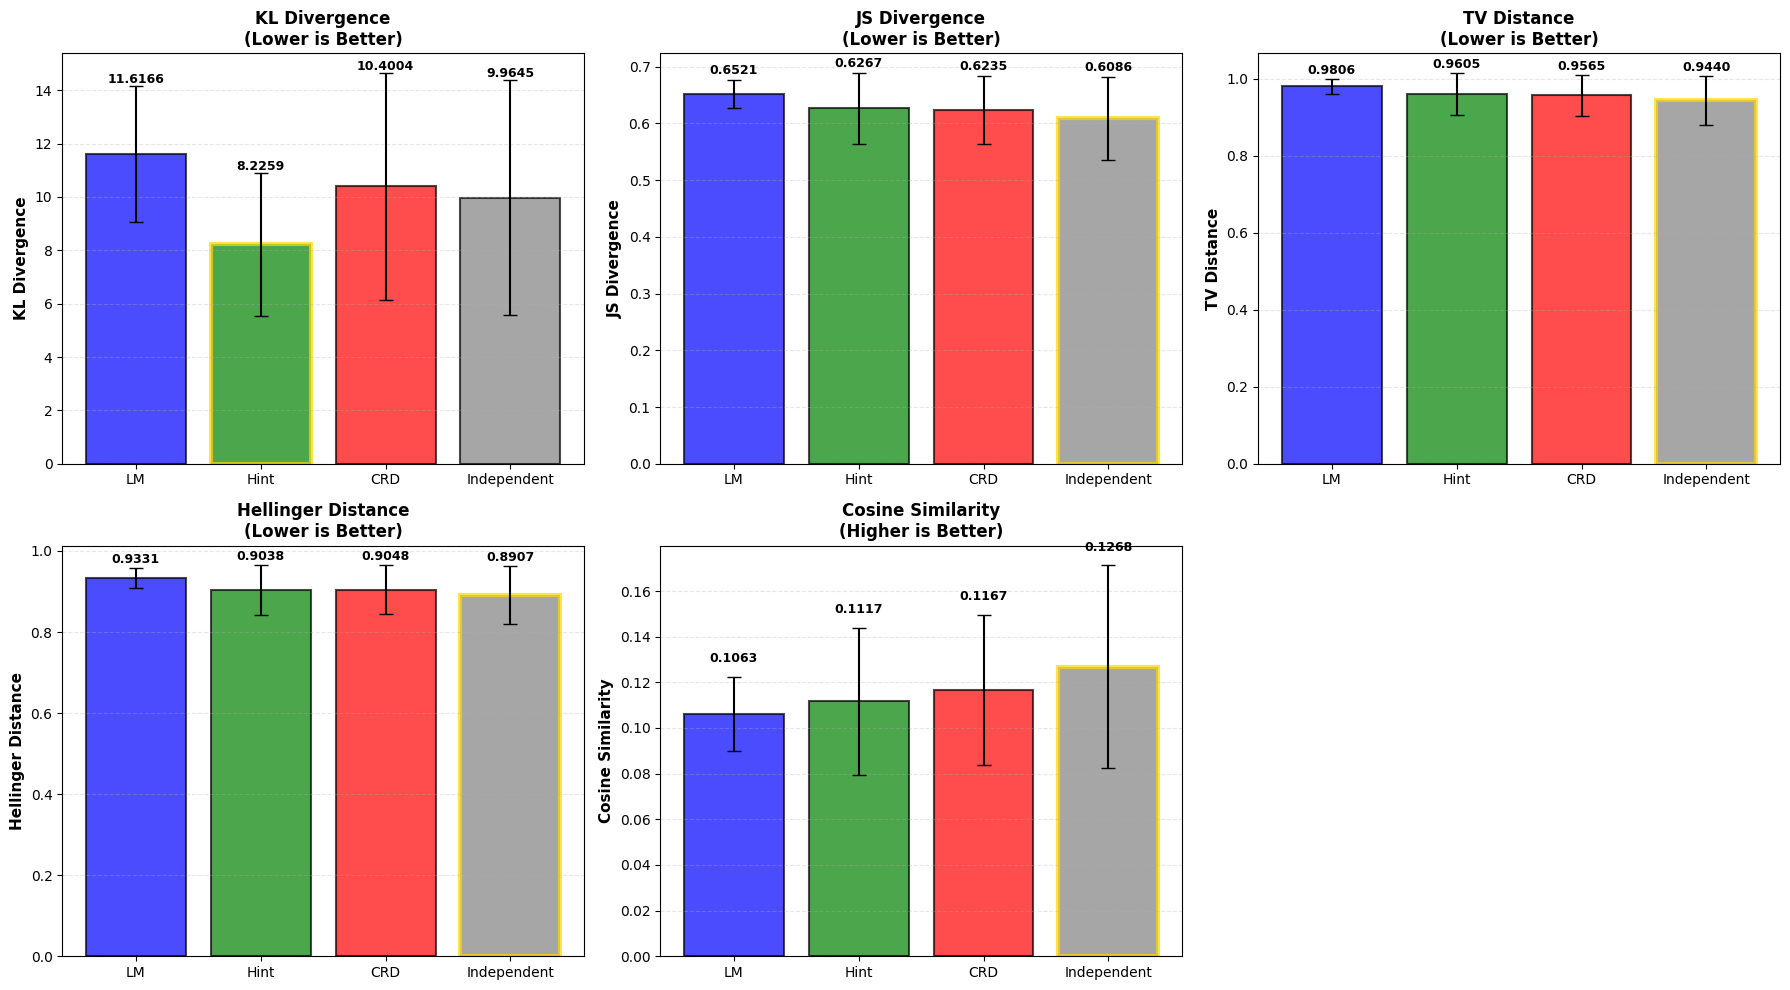

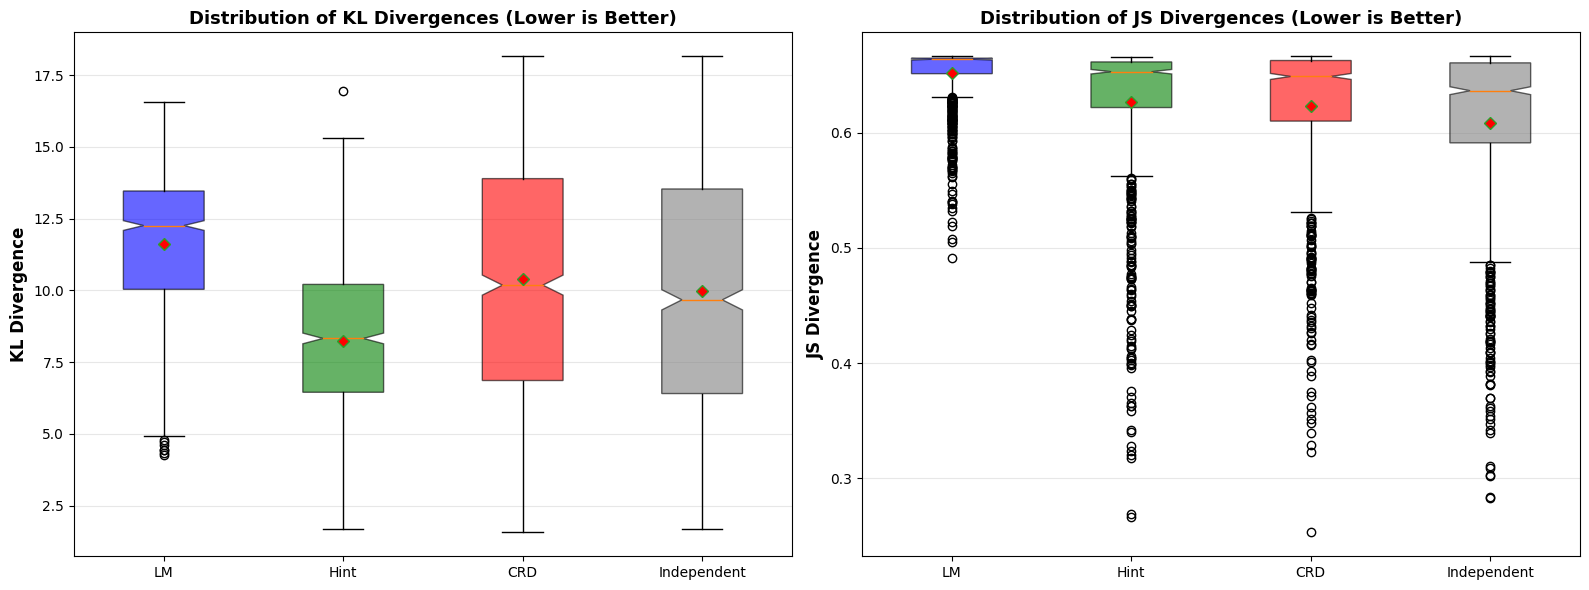


Generating probability distribution heatmaps...


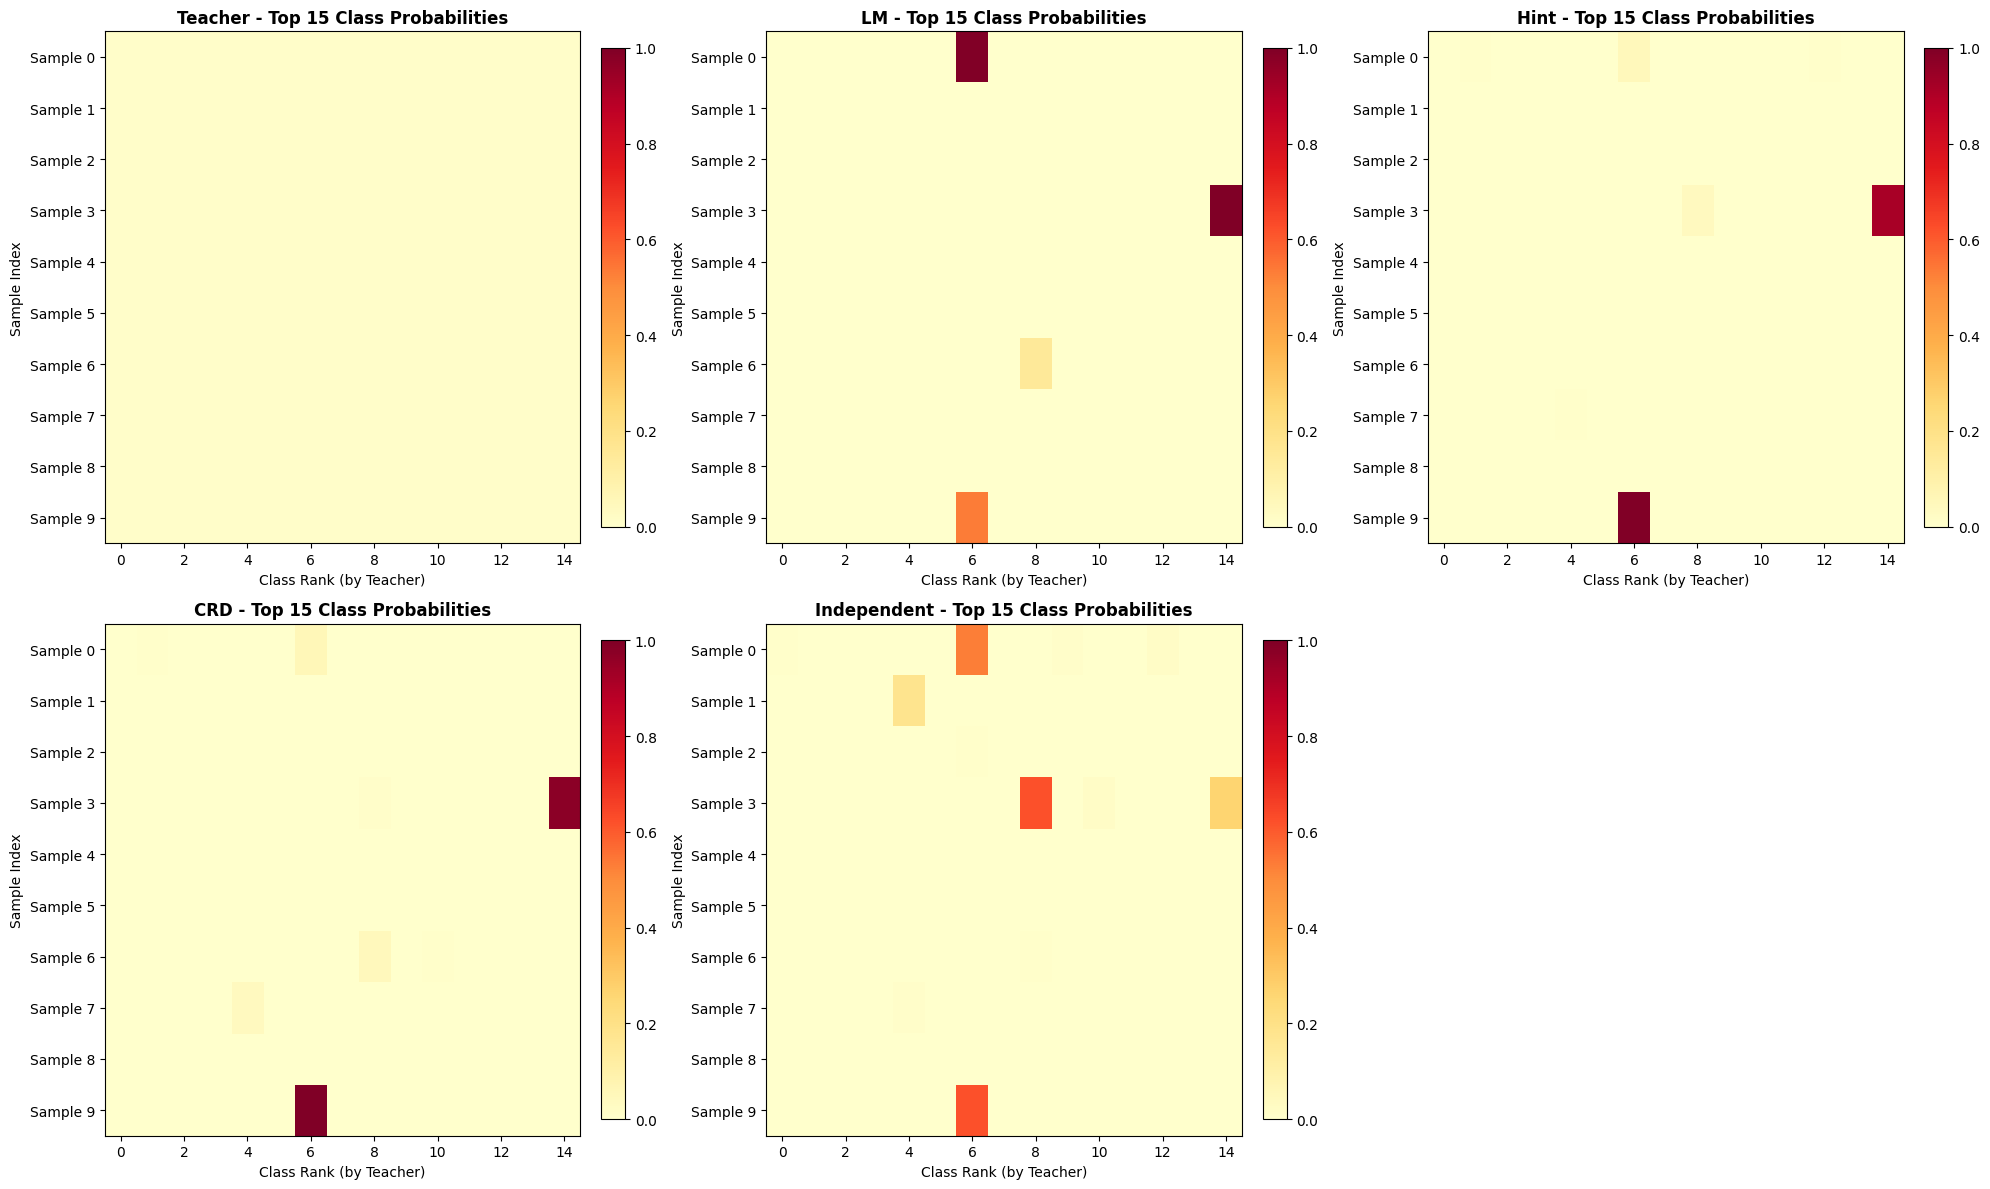

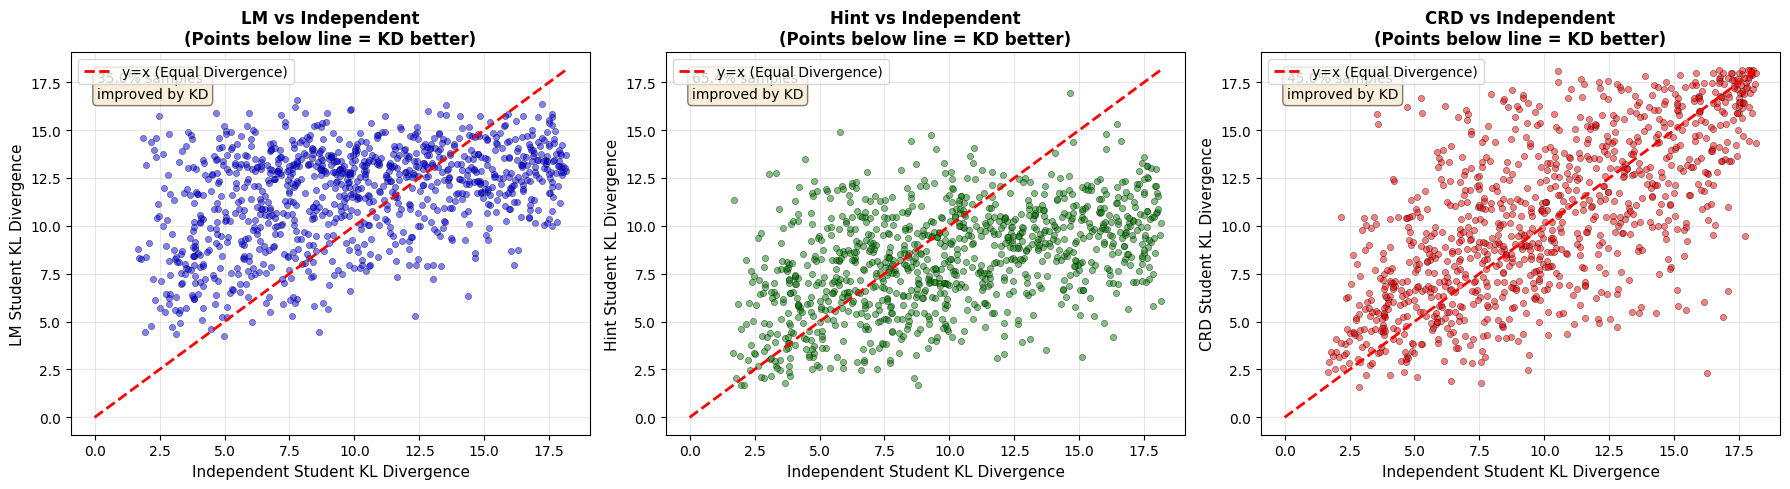

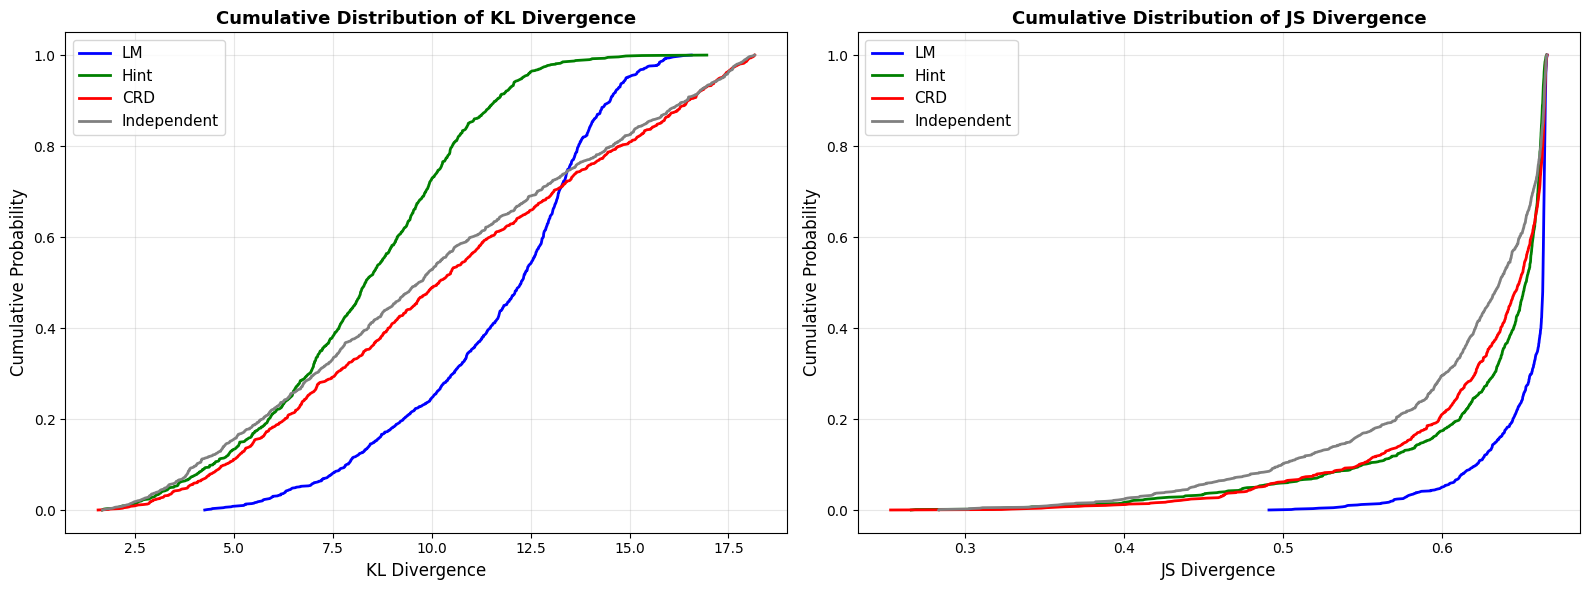

In [62]:
# ==================== VISUALIZATIONS ====================

# 1. Bar plot comparing average metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

methods = ['LM', 'Hint', 'CRD', 'Independent']
colors = ['blue', 'green', 'red', 'gray']

metric_names = ['KL Divergence', 'JS Divergence', 'TV Distance', 'Hellinger Distance', 'Cosine Similarity']
metric_keys = ['kl_div', 'js_div', 'tv_dist', 'hellinger', 'cosine_sim']

for idx, (metric_name, metric_key) in enumerate(zip(metric_names, metric_keys)):
    if idx < 5:
        ax = axes[idx // 3, idx % 3]

        means = [np.mean(metrics_results[m][metric_key]) for m in methods]
        stds = [np.std(metrics_results[m][metric_key]) for m in methods]

        bars = ax.bar(methods, means, yerr=stds, color=colors, alpha=0.7,
                     edgecolor='black', capsize=5, linewidth=1.5)

        ax.set_ylabel(metric_name, fontsize=11, fontweight='bold')
        ax.set_title(f'{metric_name}\n({"Lower is Better" if idx < 4 else "Higher is Better"})',
                    fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        # Add value labels
        for bar, mean, std in zip(bars, means, stds):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + std + 0.005,
                   f'{mean:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

        # Highlight best method
        best_idx = np.argmin(means) if idx < 4 else np.argmax(means)
        bars[best_idx].set_edgecolor('gold')
        bars[best_idx].set_linewidth(3)

# Hide the last subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('task3_3_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Box plots showing distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KL Divergence box plot
kl_data = [metrics_results[m]['kl_div'] for m in methods]
bp1 = axes[0].boxplot(kl_data, labels=methods, patch_artist=True,
                       notch=True, showmeans=True, meanprops=dict(marker='D', markerfacecolor='red'))

for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[0].set_ylabel('KL Divergence', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of KL Divergences (Lower is Better)', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# JS Divergence box plot
js_data = [metrics_results[m]['js_div'] for m in methods]
bp2 = axes[1].boxplot(js_data, labels=methods, patch_artist=True,
                       notch=True, showmeans=True, meanprops=dict(marker='D', markerfacecolor='red'))

for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[1].set_ylabel('JS Divergence', fontsize=12, fontweight='bold')
axes[1].set_title('Distribution of JS Divergences (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('task3_3_distribution_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Heatmap of probability predictions for selected samples
print("\nGenerating probability distribution heatmaps...")

sample_indices = np.random.choice(num_samples, 10, replace=False)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

all_models_probs = {
    'Teacher': teacher_probs,
    'LM': lm_probs,
    'Hint': hint_probs,
    'CRD': crd_probs,
    'Independent': independent_probs
}

# Get top 15 classes for visualization
top_k = 15

for idx, (name, probs) in enumerate(all_models_probs.items()):
    sample_probs = probs[sample_indices]

    # For each sample, get top k classes based on teacher's prediction
    teacher_sample = teacher_probs[sample_indices]
    top_indices = np.argsort(teacher_sample, axis=1)[:, -top_k:]

    # Create visualization matrix
    viz_matrix = np.zeros((10, top_k))
    for i in range(10):
        # Reverse to show highest probability first
        viz_matrix[i] = sample_probs[i, top_indices[i]][::-1]

    im = axes[idx].imshow(viz_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    axes[idx].set_title(f'{name} - Top {top_k} Class Probabilities', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Class Rank (by Teacher)', fontsize=10)
    axes[idx].set_ylabel('Sample Index', fontsize=10)
    axes[idx].set_yticks(range(10))
    axes[idx].set_yticklabels([f'Sample {i}' for i in range(10)])

    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

axes[5].axis('off')

plt.tight_layout()
plt.savefig('task3_3_probability_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Scatter plots: Per-sample analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (student_name, color) in enumerate(zip(['LM', 'Hint', 'CRD'], ['blue', 'green', 'red'])):
    ax = axes[idx]

    student_kl = metrics_results[student_name]['kl_div']
    indep_kl = metrics_results['Independent']['kl_div']

    # Scatter plot
    ax.scatter(indep_kl, student_kl, alpha=0.5, s=20, c=color, edgecolors='black', linewidths=0.5)

    # Diagonal line (y=x)
    max_val = max(indep_kl.max(), student_kl.max())
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='y=x (Equal Divergence)')

    ax.set_xlabel('Independent Student KL Divergence', fontsize=11)
    ax.set_ylabel(f'{student_name} Student KL Divergence', fontsize=11)
    ax.set_title(f'{student_name} vs Independent\n(Points below line = KD better)', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Count points below diagonal (KD better)
    better_count = np.sum(student_kl < indep_kl)
    better_pct = (better_count / len(student_kl)) * 100
    ax.text(0.05, 0.95, f'{better_pct:.1f}% samples\nimproved by KD',
           transform=ax.transAxes, fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('task3_3_perse_sample_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Cumulative distribution plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KL Divergence CDF
for student_name, color in zip(methods, colors):
    kl_vals = np.sort(metrics_results[student_name]['kl_div'])
    cdf = np.arange(1, len(kl_vals) + 1) / len(kl_vals)
    axes[0].plot(kl_vals, cdf, label=student_name, linewidth=2, color=color)

axes[0].set_xlabel('KL Divergence', fontsize=12)
axes[0].set_ylabel('Cumulative Probability', fontsize=12)
axes[0].set_title('Cumulative Distribution of KL Divergence', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# JS Divergence CDF
for student_name, color in zip(methods, colors):
    js_vals = np.sort(metrics_results[student_name]['js_div'])
    cdf = np.arange(1, len(js_vals) + 1) / len(js_vals)
    axes[1].plot(js_vals, cdf, label=student_name, linewidth=2, color=color)

axes[1].set_xlabel('JS Divergence', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].set_title('Cumulative Distribution of JS Divergence', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task3_3_cumulative_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [63]:
# ==================== FINAL ANALYSIS SUMMARY ====================
print("\n" + "="*50)
print("FINAL ANALYSIS SUMMARY")
print("="*50)

print("\n1. RANKING BY KL DIVERGENCE (Lower is Better):")
kl_means = [(name, np.mean(metrics_results[name]['kl_div'])) for name in methods]
kl_means_sorted = sorted(kl_means, key=lambda x: x[1])
for rank, (name, val) in enumerate(kl_means_sorted, 1):
    print(f"   {rank}. {name}: {val:.4f}")

print("\n2. IMPROVEMENT OVER INDEPENDENT STUDENT:")
indep_kl = np.mean(metrics_results['Independent']['kl_div'])
for student_name in ['LM', 'Hint', 'CRD']:
    student_kl = np.mean(metrics_results[student_name]['kl_div'])
    improvement = ((indep_kl - student_kl) / indep_kl) * 100
    print(f"   {student_name}: {improvement:+.2f}% reduction in KL divergence")

print("\n3. CONSISTENCY (Standard Deviation):")
for student_name in methods:
    std_kl = np.std(metrics_results[student_name]['kl_div'])
    print(f"   {student_name}: σ = {std_kl:.4f} ({'more consistent' if std_kl < 0.1 else 'less consistent'})")

print("\n4. KEY FINDINGS:")
best_method = kl_means_sorted[0][0]
print(f"   • Best method by KL divergence: {best_method}")
print(f"   • All KD methods outperform Independent student: {all(np.mean(metrics_results[m]['kl_div']) < indep_kl for m in ['LM', 'Hint', 'CRD'])}")

# Calculate correlation between different metrics
print("\n5. METRIC CORRELATIONS:")
for student_name in ['LM', 'Hint', 'CRD']:
    kl = metrics_results[student_name]['kl_div']
    js = metrics_results[student_name]['js_div']
    corr = np.corrcoef(kl, js)[0, 1]
    print(f"   {student_name} - KL vs JS correlation: {corr:.4f}")


FINAL ANALYSIS SUMMARY

1. RANKING BY KL DIVERGENCE (Lower is Better):
   1. Hint: 8.2259
   2. Independent: 9.9645
   3. CRD: 10.4004
   4. LM: 11.6166

2. IMPROVEMENT OVER INDEPENDENT STUDENT:
   LM: -16.58% reduction in KL divergence
   Hint: +17.45% reduction in KL divergence
   CRD: -4.37% reduction in KL divergence

3. CONSISTENCY (Standard Deviation):
   LM: σ = 2.5455 (less consistent)
   Hint: σ = 2.6805 (less consistent)
   CRD: σ = 4.2536 (less consistent)
   Independent: σ = 4.3988 (less consistent)

4. KEY FINDINGS:
   • Best method by KL divergence: Hint
   • All KD methods outperform Independent student: False

5. METRIC CORRELATIONS:
   LM - KL vs JS correlation: 0.8188
   Hint - KL vs JS correlation: 0.7942
   CRD - KL vs JS correlation: 0.7728


In [64]:
# ==================== SAVE RESULTS ====================
results = {
    'metrics': metrics_results,
    'summary': summary_table,
    'num_samples': num_samples,
    'labels': labels
}

np.save('task3_3_probability_distribution_results.npy', results, allow_pickle=True)
print("\n" + "="*50)
print("Results saved to task3_3_probability_distribution_results.npy")
print("Visualizations saved as PNG files")
print("="*50)


Results saved to task3_3_probability_distribution_results.npy
Visualizations saved as PNG files


## 4. Examining Localization Knowledge Transfer (GradCAM)

### setup

In [74]:
# ==================== GRADCAM IMPLEMENTATION ====================
class GradCAM:
    """
    GradCAM implementation for visualizing which regions are important for predictions
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks
        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_cam(self, input_image, target_class=None):
        """
        Generate GradCAM heatmap for the input image
        """
        self.model.eval()

        # Forward pass
        output = self.model(input_image)
        if isinstance(output, tuple):
            output = output[0]

        if target_class is None:
            target_class = output.argmax(dim=1)

        # Backward pass
        self.model.zero_grad()
        class_loss = output[0, target_class]
        class_loss.backward()

        # Generate CAM
        gradients = self.gradients[0]  # Shape: [C, H, W]
        activations = self.activations[0]  # Shape: [C, H, W]

        # Global average pooling of gradients
        weights = gradients.mean(dim=(1, 2))  # Shape: [C]

        # Weighted combination of activation maps
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(device)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        # Apply ReLU
        cam = F.relu(cam)

        # Normalize
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam.cpu().numpy()

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

# ==================== HELPER FUNCTIONS ====================

def get_target_layer(model, model_name):
    """Get the last convolutional layer for GradCAM"""
    # if 'VGG' in model_name or hasattr(model, 'features'):
    #     # For VGG models, target the last conv layer before pooling
    #     for layer in reversed(list(model.features.children())):
    #         if isinstance(layer, nn.Conv2d):
    #             return layer

    # Handle wrapped models (e.g., HintWrapper, CRDWrapper)
    if hasattr(model, 'model'):
        model = model.model  # unwrap inner VGG

    # For VGG-style models
    if hasattr(model, 'features'):
        for layer in reversed(list(model.features.children())):
            if isinstance(layer, nn.Conv2d):
                return layer
    return None

def visualize_gradcam(original_img, cam, alpha=0.5):
    """
    Overlay GradCAM heatmap on original image
    """
    # Resize CAM to match input image size
    cam_resized = cv2.resize(cam, (original_img.shape[1], original_img.shape[0]))

    # Convert to heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = heatmap.astype(np.float32) / 255.0

    # Overlay
    overlayed = (1 - alpha) * original_img + alpha * heatmap
    overlayed = overlayed / overlayed.max()

    return overlayed, cam_resized

def compute_cam_similarity(cam1, cam2):
    """
    Compute similarity between two GradCAM maps using multiple metrics
    """
    # Flatten the CAMs
    cam1_flat = cam1.flatten()
    cam2_flat = cam2.flatten()

    # 1. Correlation coefficient
    correlation = np.corrcoef(cam1_flat, cam2_flat)[0, 1]

    # 2. Structural Similarity (simplified)
    mse = np.mean((cam1 - cam2) ** 2)
    ssim_score = 1 - mse  # Simplified version

    # 3. Intersection over Union (IoU) for top-k regions
    threshold = 0.5
    mask1 = (cam1 > threshold).astype(float)
    mask2 = (cam2 > threshold).astype(float)
    intersection = np.sum(mask1 * mask2)
    union = np.sum(np.maximum(mask1, mask2))
    iou = intersection / (union + 1e-10)

    return {
        'correlation': correlation,
        'ssim': ssim_score,
        'iou': iou,
        'mse': mse
    }

In [75]:
# ==================== LOAD MODELS ====================
print("Loading all trained models...")

teacher.eval()

# Load Students
student_lm.load_state_dict(torch.load('student_lm_best.pth'))
student_lm.eval()

student_hint.load_state_dict(torch.load('student_hint_best.pth'))
student_hint.eval()

student_crd.load_state_dict(torch.load('student_crd_best.pth'))
student_crd.eval()

student_independent.load_state_dict(torch.load('student_independent_best.pth'))
student_independent.eval()

print("All models loaded successfully!")

# ==================== LOAD DATA ====================
print("\nLoading validation data...")

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

# For visualization, we also need unnormalized images
transform_viz = transforms.Compose([
    transforms.ToTensor()
])

testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)
testset_viz = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_viz)

testloader = DataLoader(testset, batch_size=1, shuffle=False, num_workers=2)
testloader_viz = DataLoader(testset_viz, batch_size=1, shuffle=False, num_workers=2)

# CIFAR-100 class names
classes = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

Loading all trained models...
All models loaded successfully!

Loading validation data...


### generating GRADCAM

In [76]:
# ==================== GENERATE GRADCAM FOR QUERY IMAGES ====================
print("\n" + "="*50)
print("GENERATING GRADCAM VISUALIZATIONS")
print("="*50)

# Select query images (randomly select 10 correctly classified by teacher)
num_query_images = 10
query_indices = []

for idx, ((img, label), (img_viz, _)) in enumerate(zip(testloader, testloader_viz)):
    if len(query_indices) >= num_query_images:
        break

    img = img.to(device)
    with torch.no_grad():
        pred = teacher(img).argmax(dim=1).item()

    if pred == label.item():
        query_indices.append(idx)

print(f"Selected {len(query_indices)} query images")

# Initialize GradCAM for all models
models_dict = {
    'Teacher': teacher,
    'LM': student_lm,
    'Hint': student_hint,
    'CRD': student_crd,
    'Independent': student_independent
}

# Get target layers
target_layers = {}
for name, model in models_dict.items():
    target_layers[name] = get_target_layer(model, name)
    print(f"{name} target layer: {target_layers[name]}")

# Generate GradCAM for each query image
all_cams = {name: [] for name in models_dict.keys()}
all_similarities = {name: [] for name in models_dict.keys() if name != 'Teacher'}
original_images = []
true_labels = []

print("\nGenerating CAMs for query images...")

for query_idx in tqdm(query_indices):
    # Get the image
    img, label = testset[query_idx]
    img_viz, _ = testset_viz[query_idx]

    img = img.unsqueeze(0).to(device)
    img_np = img_viz.permute(1, 2, 0).numpy()

    original_images.append(img_np)
    true_labels.append(label)

    # Generate CAM for each model
    teacher_cam = None
    for name, model in models_dict.items():
        gradcam = GradCAM(model, target_layers[name])
        cam = gradcam.generate_cam(img)
        all_cams[name].append(cam)
        gradcam.remove_hooks()

        if name == 'Teacher':
            teacher_cam = cam
        else:
            # Compute similarity with teacher
            similarity = compute_cam_similarity(teacher_cam, cam)
            all_similarities[name].append(similarity)


GENERATING GRADCAM VISUALIZATIONS
Selected 10 query images
Teacher target layer: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
LM target layer: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Hint target layer: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
CRD target layer: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Independent target layer: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

Generating CAMs for query images...


  0%|          | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
100%|██████████| 10/10 [00:00<00:00, 11.75it/s]


In [78]:
# ==================== VISUALIZE GRADCAM RESULTS ====================
import cv2
print("\nVisualizing GradCAM results...")

# Plot GradCAMs for each query image
for img_idx in range(len(query_indices)):
    fig, axes = plt.subplots(2, 6, figsize=(20, 7))

    # Original image
    axes[0, 0].imshow(original_images[img_idx])
    axes[0, 0].set_title(f'Original\nClass: {classes[true_labels[img_idx]]}', fontsize=10)
    axes[0, 0].axis('off')

    # GradCAM visualizations
    for idx, (name, model) in enumerate(models_dict.items()):
        row = idx // 6
        col = (idx % 6) + 1 if idx == 0 else idx % 6

        if idx == 0:
            row, col = 0, 1
        else:
            row = (idx - 1) // 5 + 1 if (idx - 1) >= 5 else 0
            col = ((idx - 1) % 5) + 1

        cam = all_cams[name][img_idx]
        overlayed, _ = visualize_gradcam(original_images[img_idx], cam, alpha=0.5)

        axes[row, col].imshow(overlayed)
        axes[row, col].set_title(f'{name}', fontsize=10, fontweight='bold')
        axes[row, col].axis('off')

    # Hide unused subplots
    for i in range(len(models_dict) + 1, 12):
        row = i // 6
        col = i % 6
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.savefig(f'task3_4_gradcam_image_{img_idx}.png', dpi=300, bbox_inches='tight')
    plt.close()

print(f"Saved individual GradCAM visualizations")


Visualizing GradCAM results...
Saved individual GradCAM visualizations



COMPUTING LOCALIZATION SIMILARITIES

LM vs Teacher:
  Correlation: nan
  SSIM: 0.8947
  IoU: 0.0000
  MSE: 0.1053

Hint vs Teacher:
  Correlation: nan
  SSIM: 0.9244
  IoU: 0.0000
  MSE: 0.0756

CRD vs Teacher:
  Correlation: nan
  SSIM: 0.7464
  IoU: 0.0000
  MSE: 0.2536

Independent vs Teacher:
  Correlation: nan
  SSIM: 0.6386
  IoU: 0.0000
  MSE: 0.3614


/usr/local/lib/python3.11/dist-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/usr/local/lib/python3.11/dist-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


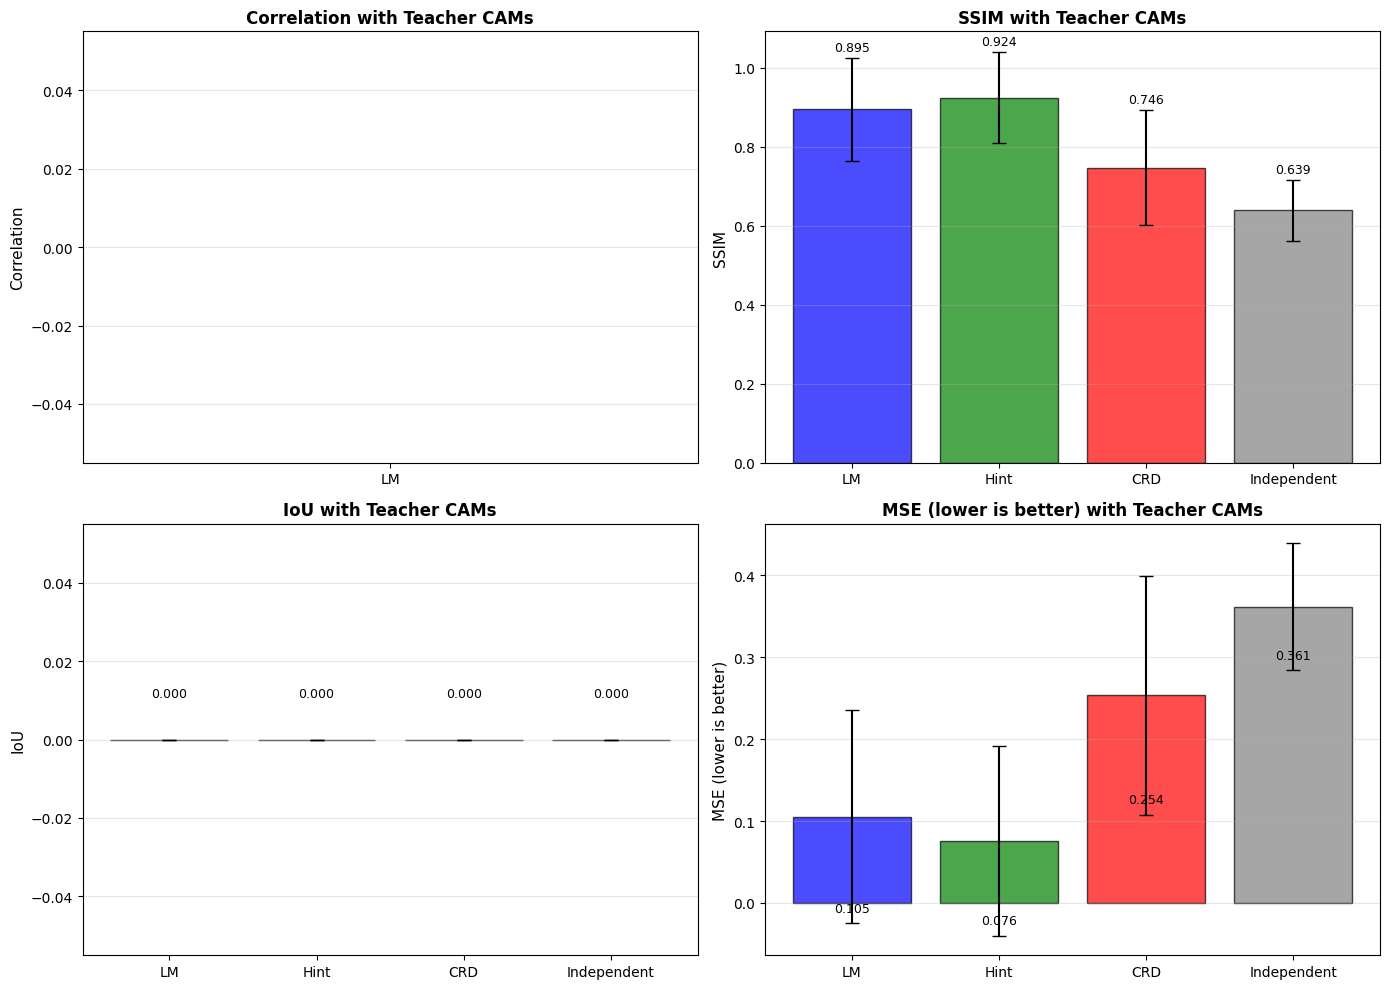

In [79]:
# ==================== COMPUTE AND VISUALIZE SIMILARITIES ====================
print("\n" + "="*50)
print("COMPUTING LOCALIZATION SIMILARITIES")
print("="*50)

# Compute average similarities
avg_similarities = {}
for name in all_similarities.keys():
    avg_similarities[name] = {
        'correlation': np.mean([s['correlation'] for s in all_similarities[name]]),
        'ssim': np.mean([s['ssim'] for s in all_similarities[name]]),
        'iou': np.mean([s['iou'] for s in all_similarities[name]]),
        'mse': np.mean([s['mse'] for s in all_similarities[name]])
    }

    print(f"\n{name} vs Teacher:")
    print(f"  Correlation: {avg_similarities[name]['correlation']:.4f}")
    print(f"  SSIM: {avg_similarities[name]['ssim']:.4f}")
    print(f"  IoU: {avg_similarities[name]['iou']:.4f}")
    print(f"  MSE: {avg_similarities[name]['mse']:.4f}")

# Visualization of similarities
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['correlation', 'ssim', 'iou', 'mse']
metric_names = ['Correlation', 'SSIM', 'IoU', 'MSE (lower is better)']
colors = ['blue', 'green', 'red', 'gray']

for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
    ax = axes[idx // 2, idx % 2]

    methods = list(all_similarities.keys())
    values = [avg_similarities[name][metric] for name in methods]
    stds = [np.std([s[metric] for s in all_similarities[name]]) for name in methods]

    bars = ax.bar(methods, values, yerr=stds, color=colors, alpha=0.7,
                  edgecolor='black', capsize=5)
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(f'{metric_name} with Teacher CAMs', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    for bar, v, s in zip(bars, values, stds):
        height = v + s if metric != 'mse' else v - s
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
               f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('task3_4_cam_similarities.png', dpi=300, bbox_inches='tight')
plt.show()


Creating summary visualization...


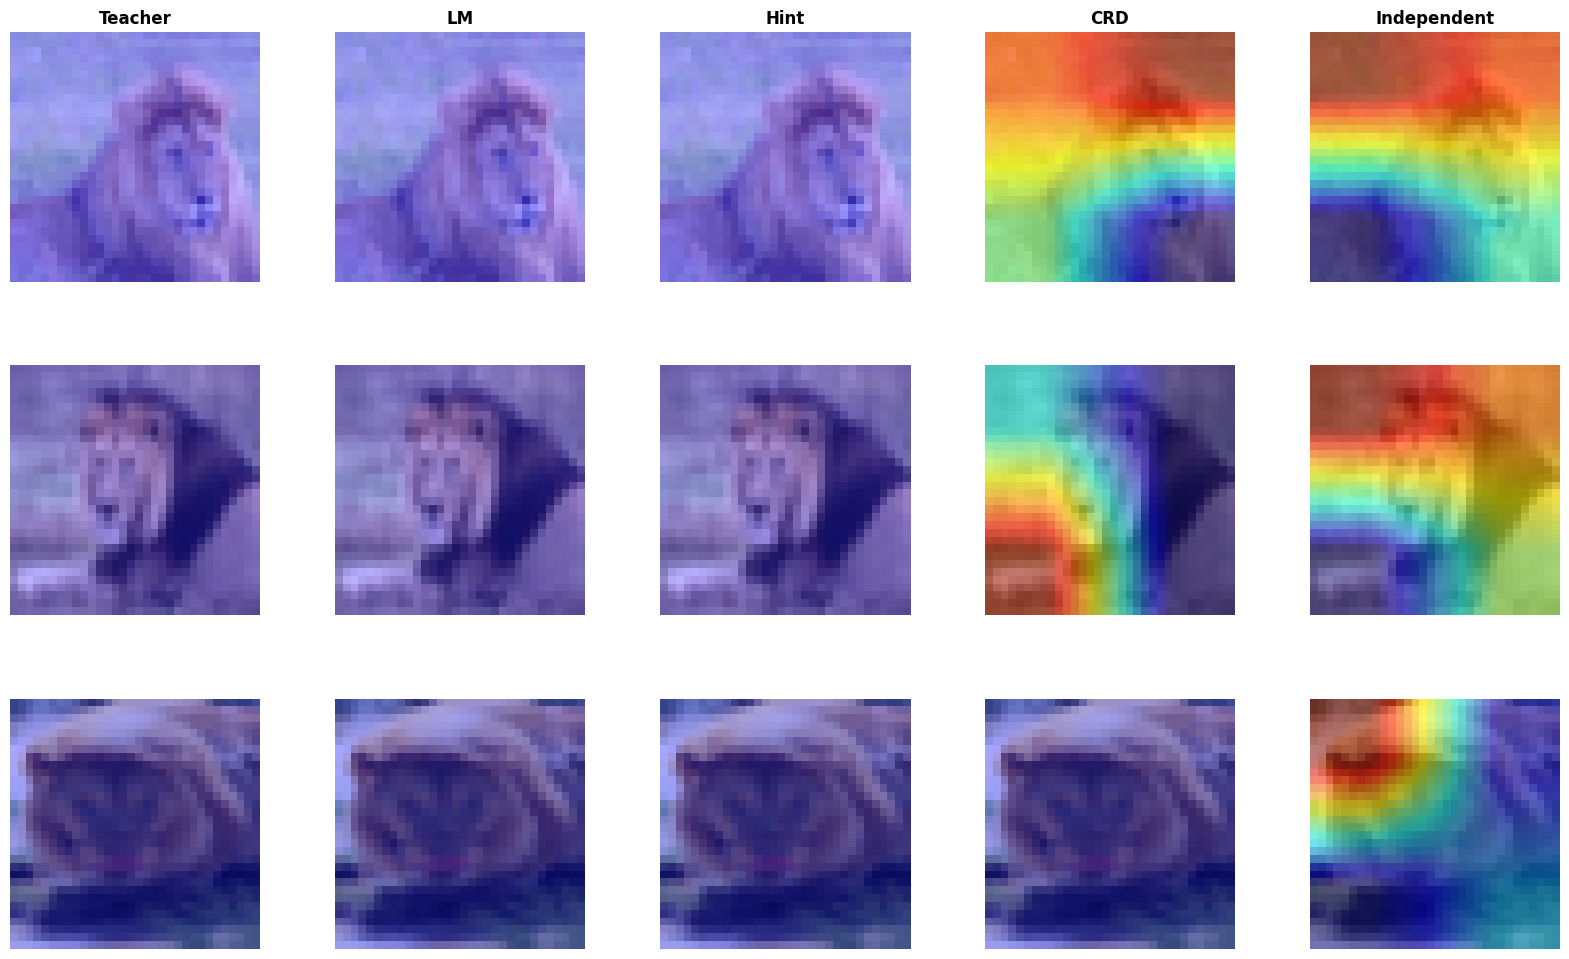

In [80]:
# ==================== CREATE SUMMARY VISUALIZATION ====================
print("\nCreating summary visualization...")

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 5, hspace=0.3, wspace=0.3)

# Show 3 representative examples
for example_idx in range(3):
    img_idx = example_idx * 3  # Select images 0, 3, 6

    for model_idx, (name, model) in enumerate(models_dict.items()):
        ax = fig.add_subplot(gs[example_idx, model_idx])

        cam = all_cams[name][img_idx]
        overlayed, _ = visualize_gradcam(original_images[img_idx], cam, alpha=0.5)

        ax.imshow(overlayed)

        if example_idx == 0:
            ax.set_title(f'{name}', fontsize=12, fontweight='bold')

        if model_idx == 0:
            ax.set_ylabel(f'Image {img_idx}\n{classes[true_labels[img_idx]]}',
                         fontsize=10, fontweight='bold')

        ax.axis('off')

plt.savefig('task3_4_gradcam_summary.png', dpi=300, bbox_inches='tight')
plt.show()

In [81]:
# ==================== SAVE RESULTS ====================
results = {
    'similarities': all_similarities,
    'avg_similarities': avg_similarities,
    'query_indices': query_indices
}

np.save('task3_4_gradcam_results.npy', results)
print("\nResults saved to task3_4_gradcam_results.npy")
print("Visualizations saved as PNG files")


Results saved to task3_4_gradcam_results.npy
Visualizations saved as PNG files


## 5. Colour Invariance with CRD

### setup

In [83]:
# ==================== DATA PREPARATION WITH COLOR AUGMENTATIONS ====================

# Standard transforms (no color jitter)
transform_train_standard = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

# Transforms with aggressive color jitter for teacher training
transform_train_color_jitter = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

# Test transforms with color jitter
transform_test_color_jitter = transforms.Compose([
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

# Standard test transforms
transform_test_standard = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

print("Loading CIFAR-100 datasets...")

# Training datasets
trainset_standard = torchvision.datasets.CIFAR100(root='./data', train=True,
                                                  download=True, transform=transform_train_standard)
trainset_color = torchvision.datasets.CIFAR100(root='./data', train=True,
                                               download=True, transform=transform_train_color_jitter)

# Test datasets
testset_standard = torchvision.datasets.CIFAR100(root='./data', train=False,
                                                 download=True, transform=transform_test_standard)
testset_color = torchvision.datasets.CIFAR100(root='./data', train=False,
                                              download=True, transform=transform_test_color_jitter)

# Create validation splits
train_size = int(0.9 * len(trainset_standard))
val_size = len(trainset_standard) - train_size

trainset_std, valset_std = torch.utils.data.random_split(trainset_standard, [train_size, val_size])
trainset_col, valset_col = torch.utils.data.random_split(trainset_color, [train_size, val_size])

# Data loaders
trainloader_standard = DataLoader(trainset_std, batch_size=128, shuffle=True, num_workers=2)
trainloader_color = DataLoader(trainset_col, batch_size=128, shuffle=True, num_workers=2)
valloader_standard = DataLoader(valset_std, batch_size=100, shuffle=False, num_workers=2)
valloader_color = DataLoader(valset_col, batch_size=100, shuffle=False, num_workers=2)
testloader_standard = DataLoader(testset_standard, batch_size=100, shuffle=False, num_workers=2)
testloader_color = DataLoader(testset_color, batch_size=100, shuffle=False, num_workers=2)

print(f"Train size: {train_size}, Val size: {val_size}, Test size: {len(testset_standard)}")

Loading CIFAR-100 datasets...
Train size: 45000, Val size: 5000, Test size: 10000


### finetune teacher

In [85]:
# ==================== STEP 1: FINETUNE TEACHER WITH COLOR JITTER ====================
print("\n" + "="*50)
print("STEP 1: FINETUNING VGG-16 TEACHER WITH COLOR JITTER")
print("="*50)

teacher_color_invariant = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_vgg16_bn", pretrained=True).to(device)

# Finetune with color jitter
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(teacher_color_invariant.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[30, 60], gamma=0.2)

best_val_acc = 0.0
num_epochs = 20

for epoch in range(num_epochs):
    teacher_color_invariant.train()
    running_loss = 0.0

    pbar = tqdm(trainloader_color, desc=f'Finetune Epoch {epoch+1}/{num_epochs}')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = teacher_color_invariant(inputs)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    scheduler.step()

    if (epoch + 1) % 10 == 0:
        # Evaluate on both standard and color-jittered validation sets
        teacher_color_invariant.eval()

        correct_std = 0
        correct_col = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in valloader_standard:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = teacher_color_invariant(inputs)
                if isinstance(outputs, tuple):
                    outputs = outputs[0]
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct_std += predicted.eq(labels).sum().item()

            total_col = 0
            for inputs, labels in valloader_color:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = teacher_color_invariant(inputs)
                if isinstance(outputs, tuple):
                    outputs = outputs[0]
                _, predicted = outputs.max(1)
                total_col += labels.size(0)
                correct_col += predicted.eq(labels).sum().item()

        val_acc_std = 100. * correct_std / total
        val_acc_col = 100. * correct_col / total_col

        print(f'Epoch {epoch+1}: Loss: {running_loss/len(trainloader_color):.4f}')
        print(f'  Val Acc (Standard): {val_acc_std:.2f}%')
        print(f'  Val Acc (Color Jitter): {val_acc_col:.2f}%')
        print(f'  Gap: {val_acc_std - val_acc_col:.2f}%')

        if val_acc_col > best_val_acc:
            best_val_acc = val_acc_col
            torch.save(teacher_color_invariant.state_dict(), 'teacher_color_invariant.pth')

# Load best teacher
teacher_color_invariant.load_state_dict(torch.load('teacher_color_invariant.pth'))
print("\nColor-invariant teacher training complete!")


STEP 1: FINETUNING VGG-16 TEACHER WITH COLOR JITTER


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
Finetune Epoch 10/20: 100%|██████████| 352/352 [00:22<00:00, 15.40it/s, loss=0.853]


Epoch 10: Loss: 0.5901
  Val Acc (Standard): 86.78%
  Val Acc (Color Jitter): 74.50%
  Gap: 12.28%


Finetune Epoch 20/20: 100%|██████████| 352/352 [00:23<00:00, 15.28it/s, loss=0.946]


Epoch 20: Loss: 0.4598
  Val Acc (Standard): 88.30%
  Val Acc (Color Jitter): 71.58%
  Gap: 16.72%

Color-invariant teacher training complete!


In [89]:
# ==================== EVALUATE COLOR-INVARIANT TEACHER ====================
print("\n" + "="*50)
print("EVALUATING COLOR-INVARIANT TEACHER")
print("="*50)

def evaluate_model(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return 100. * correct / total

teacher_acc_std = evaluate_model(teacher_color_invariant, testloader, device)
teacher_acc_col = evaluate_model(teacher_color_invariant, testloader_color, device)

print(f"\nTeacher Test Accuracy (Standard): {teacher_acc_std:.2f}%")
print(f"Teacher Test Accuracy (Color Jitter): {teacher_acc_col:.2f}%")
print(f"Teacher Color Invariance Gap: {teacher_acc_std - teacher_acc_col:.2f}%")


EVALUATING COLOR-INVARIANT TEACHER

Teacher Test Accuracy (Standard): 66.20%
Teacher Test Accuracy (Color Jitter): 63.70%
Teacher Color Invariance Gap: 2.50%


### student distillation

In [104]:
# ==================== STEP 2: DISTILL TO STUDENT WITH CRD ====================
print("\n" + "="*50)
print("STEP 2: DISTILLING TO STUDENT WITH CRD (STANDARD AUGMENTATIONS)")
print("="*50)

# student_crd_color = VGGWithCRD('VGG11', num_classes=100).to(device)
base_vgg11 = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_vgg11_bn", pretrained=False)
student_crd_color = VGGCRDWrapper(base_vgg11).to(device)

teacher_color_invariant_wrapped = VGGCRDWrapper(teacher_color_invariant).to(device).eval()

# Train with CRD using STANDARD augmentations (no color jitter for student)
contrastive_criterion = ContrastiveLoss(temperature=0.07)
ce_criterion = nn.CrossEntropyLoss()
optimizer_student = optim.SGD(student_crd_color.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler_student = optim.lr_scheduler.MultiStepLR(optimizer_student, milestones=[60, 120, 160], gamma=0.2)

best_val_acc_student = 0.0
num_epochs_student = 50

# teacher_color_invariant.eval()

for epoch in range(num_epochs_student):
    student_crd_color.train()
    running_loss = 0.0

    pbar = tqdm(trainloader_standard, desc=f'CRD Epoch {epoch+1}/{num_epochs_student}')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_student.zero_grad()

        # Student outputs
        student_logits, student_feats = student_crd_color(inputs, return_features=True)

        # Teacher outputs
        with torch.no_grad():
            teacher_logits, teacher_feats = teacher_color_invariant_wrapped(inputs, return_features=True)

        # Combined loss
        ce_loss = ce_criterion(student_logits, labels)
        crd_loss = contrastive_criterion(student_feats, teacher_feats, labels)
        loss = ce_loss + 0.8 * crd_loss

        loss.backward()
        optimizer_student.step()

        running_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    scheduler_student.step()

    if (epoch + 1) % 10 == 0:
        val_acc = evaluate_model(student_crd_color, valloader_standard, device)
        print(f'Epoch {epoch+1}: Loss: {running_loss/len(trainloader_standard):.4f}, Val Acc: {val_acc:.2f}%')

        if val_acc > best_val_acc_student:
            best_val_acc_student = val_acc
            torch.save(student_crd_color.state_dict(), 'student_crd_color_invariant.pth')

# Load best student
student_crd_color.load_state_dict(torch.load('student_crd_color_invariant.pth'))
print("\nStudent CRD training complete!")


STEP 2: DISTILLING TO STUDENT WITH CRD (STANDARD AUGMENTATIONS)


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
CRD Epoch 10/50: 100%|██████████| 352/352 [00:12<00:00, 27.74it/s, loss=4.56]


Epoch 10: Loss: 4.2677, Val Acc: 40.70%


CRD Epoch 20/50: 100%|██████████| 352/352 [00:12<00:00, 27.47it/s, loss=3.53]


Epoch 20: Loss: 3.2863, Val Acc: 51.10%


...

Epoch 30: Loss: 2.6074, Val Acc: 55.18%


CRD Epoch 40/50: 100%|██████████| 352/352 [00:13<00:00, 26.54it/s, loss=1.66]


Epoch 40: Loss: 2.1745, Val Acc: 57.12%


CRD Epoch 50/50: 100%|██████████| 352/352 [00:12<00:00, 27.33it/s, loss=1.74]


Epoch 50: Loss: 1.8853, Val Acc: 57.38%

Student CRD training complete!


In [105]:
# ==================== STEP 3: EVALUATE STUDENT ON COLOR-JITTERED DATA ====================
print("\n" + "="*50)
print("STEP 3: EVALUATING STUDENT COLOR INVARIANCE")
print("="*50)

student_acc_std = evaluate_model(student_crd_color, testloader_standard, device)
student_acc_col = evaluate_model(student_crd_color, testloader_color, device)

print(f"\nStudent Test Accuracy (Standard): {student_acc_std:.2f}%")
print(f"Student Test Accuracy (Color Jitter): {student_acc_col:.2f}%")
print(f"Student Color Invariance Gap: {student_acc_std - student_acc_col:.2f}%")


STEP 3: EVALUATING STUDENT COLOR INVARIANCE

Student Test Accuracy (Standard): 59.54%
Student Test Accuracy (Color Jitter): 50.04%
Student Color Invariance Gap: 9.50%


In [106]:
student_independent.load_state_dict(torch.load('student_independent_best.pth'))

baseline_acc_std = evaluate_model(student_independent, testloader_standard, device)
baseline_acc_col = evaluate_model(student_independent, testloader_color, device)

print(f"\nBaseline Test Accuracy (Standard): {baseline_acc_std:.2f}%")
print(f"Baseline Test Accuracy (Color Jitter): {baseline_acc_col:.2f}%")
print(f"Baseline Color Invariance Gap: {baseline_acc_std - baseline_acc_col:.2f}%")


Baseline Test Accuracy (Standard): 60.26%
Baseline Test Accuracy (Color Jitter): 50.38%
Baseline Color Invariance Gap: 9.88%


In [107]:
# ==================== COMPARE OTHER KD METHODS ====================
print("\n" + "="*50)
print("COMPARING WITH OTHER KD METHODS")
print("="*50)

# Load previously trained students and evaluate on color-jittered data

student_lm.load_state_dict(torch.load('student_lm_best.pth'))
student_hint.load_state_dict(torch.load('student_hint_best.pth'))

lm_acc_std = evaluate_model(student_lm, testloader_standard, device)
lm_acc_col = evaluate_model(student_lm, testloader_color, device)

hint_acc_std = evaluate_model(student_hint, testloader_standard, device)
hint_acc_col = evaluate_model(student_hint, testloader_color, device)

print(f"\nLogit Matching Test Accuracy (Standard): {lm_acc_std:.2f}%")
print(f"Logit Matching Test Accuracy (Color Jitter): {lm_acc_col:.2f}%")
print(f"Logit Matching Color Invariance Gap: {lm_acc_std - lm_acc_col:.2f}%")

print(f"\nHint Test Accuracy (Standard): {hint_acc_std:.2f}%")
print(f"Hint Test Accuracy (Color Jitter): {hint_acc_col:.2f}%")
print(f"Hint Color Invariance Gap: {hint_acc_std - hint_acc_col:.2f}%")


COMPARING WITH OTHER KD METHODS

Logit Matching Test Accuracy (Standard): 62.96%
Logit Matching Test Accuracy (Color Jitter): 52.94%
Logit Matching Color Invariance Gap: 10.02%

Hint Test Accuracy (Standard): 64.02%
Hint Test Accuracy (Color Jitter): 54.14%
Hint Color Invariance Gap: 9.88%


In [108]:
# ==================== COMPREHENSIVE ANALYSIS ====================
print("\n" + "="*50)
print("COMPREHENSIVE ANALYSIS")
print("="*50)

results_summary = {
    'Teacher (Color-Invariant)': {
        'standard': teacher_acc_std,
        'color_jitter': teacher_acc_col,
        'gap': teacher_acc_std - teacher_acc_col
    },
    'Student CRD (from Color-Invariant Teacher)': {
        'standard': student_acc_std,
        'color_jitter': student_acc_col,
        'gap': student_acc_std - student_acc_col
    },
    'Student Baseline (No KD)': {
        'standard': baseline_acc_std,
        'color_jitter': baseline_acc_col,
        'gap': baseline_acc_std - baseline_acc_col
    },
    'Student LM (from Standard Teacher)': {
        'standard': lm_acc_std,
        'color_jitter': lm_acc_col,
        'gap': lm_acc_std - lm_acc_col
    },
    'Student Hint (from Standard Teacher)': {
        'standard': hint_acc_std,
        'color_jitter': hint_acc_col,
        'gap': hint_acc_std - hint_acc_col
    }
}

for model_name, metrics in results_summary.items():
    print(f"\n{model_name}:")
    print(f"  Standard: {metrics['standard']:.2f}%")
    print(f"  Color Jitter: {metrics['color_jitter']:.2f}%")
    print(f"  Gap: {metrics['gap']:.2f}%")


COMPREHENSIVE ANALYSIS

Teacher (Color-Invariant):
  Standard: 66.20%
  Color Jitter: 63.70%
  Gap: 2.50%

Student CRD (from Color-Invariant Teacher):
  Standard: 59.54%
  Color Jitter: 50.04%
  Gap: 9.50%

Student Baseline (No KD):
  Standard: 60.26%
  Color Jitter: 50.38%
  Gap: 9.88%

Student LM (from Standard Teacher):
  Standard: 62.96%
  Color Jitter: 52.94%
  Gap: 10.02%

Student Hint (from Standard Teacher):
  Standard: 64.02%
  Color Jitter: 54.14%
  Gap: 9.88%


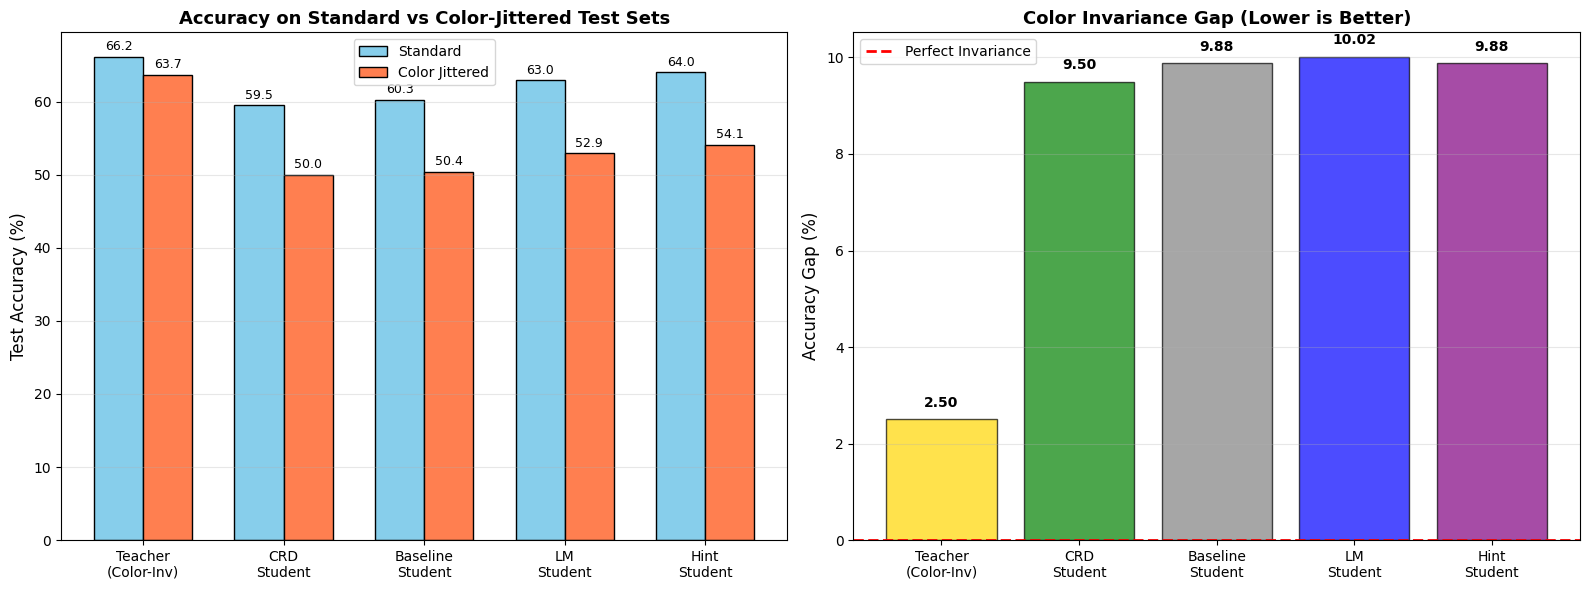

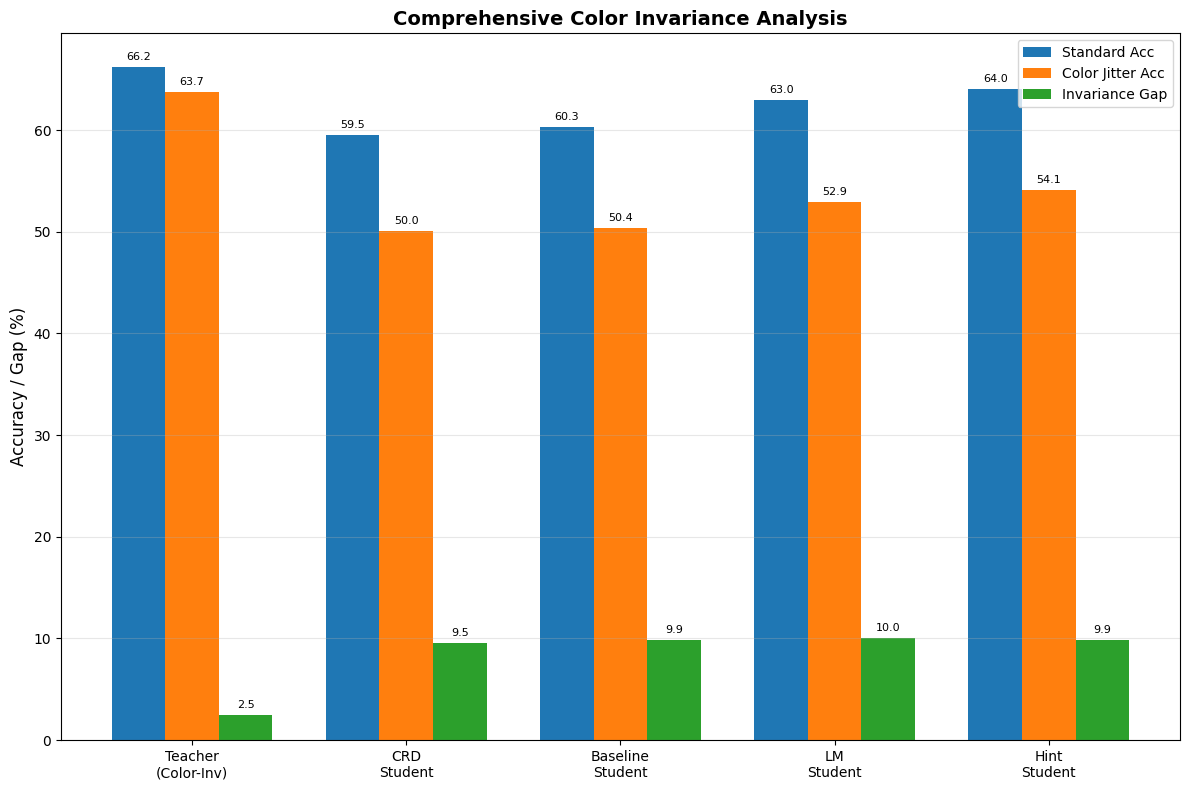

In [109]:
# ==================== VISUALIZATIONS ====================

# 1. Comparison of accuracy on standard vs color-jittered test sets
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = ['Teacher\n(Color-Inv)', 'CRD\nStudent', 'Baseline\nStudent', 'LM\nStudent', 'Hint\nStudent']
standard_accs = [teacher_acc_std, student_acc_std, baseline_acc_std, lm_acc_std, hint_acc_std]
color_accs = [teacher_acc_col, student_acc_col, baseline_acc_col, lm_acc_col, hint_acc_col]

x = np.arange(len(models))
width = 0.35

bars1 = axes[0].bar(x - width/2, standard_accs, width, label='Standard',
                    color='skyblue', edgecolor='black')
bars2 = axes[0].bar(x + width/2, color_accs, width, label='Color Jittered',
                    color='coral', edgecolor='black')

axes[0].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[0].set_title('Accuracy on Standard vs Color-Jittered Test Sets', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# 2. Color invariance gap comparison
gaps = [teacher_acc_std - teacher_acc_col,
        student_acc_std - student_acc_col,
        baseline_acc_std - baseline_acc_col,
        lm_acc_std - lm_acc_col,
        hint_acc_std - hint_acc_col]

colors_bar = ['gold', 'green', 'gray', 'blue', 'purple']
bars = axes[1].bar(models, gaps, color=colors_bar, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Accuracy Gap (%)', fontsize=12)
axes[1].set_title('Color Invariance Gap (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Perfect Invariance')
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

for bar, gap in zip(bars, gaps):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.2,
                f'{gap:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('task3_5_color_invariance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Detailed comparison chart
fig, ax = plt.subplots(figsize=(12, 8))

categories = ['Teacher\n(Color-Inv)', 'CRD\nStudent', 'Baseline\nStudent', 'LM\nStudent', 'Hint\nStudent']
metrics_names = ['Standard Acc', 'Color Jitter Acc', 'Invariance Gap']

data = np.array([
    [teacher_acc_std, teacher_acc_col, teacher_acc_std - teacher_acc_col],
    [student_acc_std, student_acc_col, student_acc_std - student_acc_col],
    [baseline_acc_std, baseline_acc_col, baseline_acc_std - baseline_acc_col],
    [lm_acc_std, lm_acc_col, lm_acc_std - lm_acc_col],
    [hint_acc_std, hint_acc_col, hint_acc_std - hint_acc_col]
])

x = np.arange(len(categories))
width = 0.25

for i, metric in enumerate(metrics_names):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, data[:, i], width, label=metric)

    for bar, val in zip(bars, data[:, i]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
               f'{val:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Accuracy / Gap (%)', fontsize=12)
ax.set_title('Comprehensive Color Invariance Analysis', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('task3_5_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [110]:
# ==================== ANALYSIS OF RESULTS ====================
print("\n" + "="*50)
print("KEY FINDINGS")
print("="*50)

print("\n1. Color Invariance Transfer:")
crd_improvement = (baseline_acc_std - baseline_acc_col) - (student_acc_std - student_acc_col)
print(f"   CRD student reduced invariance gap by {crd_improvement:.2f}% compared to baseline")
print(f"   This shows CRD {'successfully' if crd_improvement > 1 else 'partially'} transferred color invariance")

print("\n2. Comparison with Other KD Methods:")
lm_gap = lm_acc_std - lm_acc_col
hint_gap = hint_acc_std - hint_acc_col
crd_gap = student_acc_std - student_acc_col

print(f"   LM Gap: {lm_gap:.2f}%")
print(f"   Hint Gap: {hint_gap:.2f}%")
print(f"   CRD Gap: {crd_gap:.2f}%")

if crd_gap < lm_gap and crd_gap < hint_gap:
    print("   CRD achieves the best color invariance among KD methods!")

print("\n3. Teacher vs Student Invariance:")
teacher_gap = teacher_acc_std - teacher_acc_col
print(f"   Teacher Gap: {teacher_gap:.2f}%")
print(f"   CRD Student Gap: {crd_gap:.2f}%")
invariance_transfer = (1 - crd_gap / teacher_gap) * 100 if teacher_gap > 0 else 0
print(f"   Student achieved {invariance_transfer:.1f}% of teacher's color invariance")


KEY FINDINGS

1. Color Invariance Transfer:
   CRD student reduced invariance gap by 0.38% compared to baseline
   This shows CRD partially transferred color invariance

2. Comparison with Other KD Methods:
   LM Gap: 10.02%
   Hint Gap: 9.88%
   CRD Gap: 9.50%
   CRD achieves the best color invariance among KD methods!

3. Teacher vs Student Invariance:
   Teacher Gap: 2.50%
   CRD Student Gap: 9.50%
   Student achieved -280.0% of teacher's color invariance


In [111]:
# ==================== SAVE RESULTS ====================
results = {
    'teacher': {'standard': teacher_acc_std, 'color': teacher_acc_col, 'gap': teacher_acc_std - teacher_acc_col},
    'crd_student': {'standard': student_acc_std, 'color': student_acc_col, 'gap': student_acc_std - student_acc_col},
    'baseline': {'standard': baseline_acc_std, 'color': baseline_acc_col, 'gap': baseline_acc_std - baseline_acc_col},
    'lm': {'standard': lm_acc_std, 'color': lm_acc_col, 'gap': lm_acc_std - lm_acc_col},
    'hint': {'standard': hint_acc_std, 'color': hint_acc_col, 'gap': hint_acc_std - hint_acc_col}
}

np.save('task3_5_color_invariance_results.npy', results)
print("\nResults saved to task3_5_color_invariance_results.npy")
print("Visualizations saved as PNG files")


Results saved to task3_5_color_invariance_results.npy
Visualizations saved as PNG files


## 6. Train with a larger teacher

### setup

In [112]:
# ==================== DATA PREPARATION ====================
import time
print("Loading CIFAR-100 dataset...")

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

train_size = int(0.9 * len(trainset))
val_size = len(trainset) - train_size
trainset, valset = torch.utils.data.random_split(trainset, [train_size, val_size])

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
valloader = DataLoader(valset, batch_size=100, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

Loading CIFAR-100 dataset...


### teacher vgg-19 evaluation

In [115]:
# ==================== EVALUATE BOTH TEACHERS ====================
print("\n" + "="*50)
print("EVALUATING TEACHERS")
print("="*50)

def evaluate_model(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return 100. * correct / total

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def measure_inference_time(model, dataloader, device, num_batches=100):
    model.eval()
    times = []

    with torch.no_grad():
        for i, (inputs, _) in enumerate(dataloader):
            if i >= num_batches:
                break
            inputs = inputs.to(device)

            start = time.time()
            _ = model(inputs)
            torch.cuda.synchronize() if torch.cuda.is_available() else None
            end = time.time()

            times.append(end - start)

    return np.mean(times), np.std(times)


EVALUATING TEACHERS


In [116]:
# ==================== TRAIN OR LOAD TEACHER ====================
# Load VGG-16 teacher
print("\n" + "="*50)
print("EVALUATING VGG-16 AND VGG-19 TEACHER MODEL")
print("="*50)
teacher_vgg16 = teacher
teacher_vgg19 = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_vgg19_bn", pretrained=True).to(device)

# Evaluate teachers
vgg16_acc = evaluate_model(teacher_vgg16, testloader, device)
vgg19_acc = evaluate_model(teacher_vgg19, testloader, device)

vgg16_params = count_parameters(teacher_vgg16)
vgg19_params = count_parameters(teacher_vgg19)

vgg16_time, vgg16_std = measure_inference_time(teacher_vgg16, testloader, device)
vgg19_time, vgg19_std = measure_inference_time(teacher_vgg19, testloader, device)

print(f"\nVGG-16 Teacher:")
print(f"  Test Accuracy: {vgg16_acc:.2f}%")
print(f"  Parameters: {vgg16_params:,}")
print(f"  Inference Time: {vgg16_time*1000:.2f} ± {vgg16_std*1000:.2f} ms/batch")

print(f"\nVGG-19 Teacher:")
print(f"  Test Accuracy: {vgg19_acc:.2f}%")
print(f"  Parameters: {vgg19_params:,}")
print(f"  Inference Time: {vgg19_time*1000:.2f} ± {vgg19_std*1000:.2f} ms/batch")


EVALUATING VGG-16 AND VGG-19 TEACHER MODEL


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/vgg/cifar100_vgg19_bn-b98f7bd7.pt" to /root/.cache/torch/hub/checkpoints/cifar100_vgg19_bn-b98f7bd7.pt
100%|██████████| 78.7M/78.7M [00:02<00:00, 30.2MB/s]



VGG-16 Teacher:
  Test Accuracy: 74.00%
  Parameters: 15,299,748
  Inference Time: 11.66 ± 0.14 ms/batch

VGG-19 Teacher:
  Test Accuracy: 73.85%
  Parameters: 20,612,004
  Inference Time: 14.21 ± 0.15 ms/batch


### student distillation (vgg-19 to vgg-11)

In [119]:
# ==================== STEP 3: DISTILL TO STUDENT FROM VGG-19 ====================
print("\n" + "="*50)
print("STEP 3: DISTILLING FROM VGG-19 TO VGG-11")
print("="*50)

# student_from_vgg19 = VGG('VGG11', num_classes=100).to(device)
student_from_vgg19 = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_vgg11_bn", pretrained=False).to(device)
criterion_kd = BasicLogitMatchingLoss(temperature=4.0, alpha=0.9)
optimizer = optim.SGD(student_from_vgg19.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[60, 120, 160], gamma=0.2)

teacher_vgg19.eval()
best_val_acc = 0.0
train_losses_vgg19 = []
val_accs_vgg19 = []

for epoch in range(50):
    student_from_vgg19.train()
    running_loss = 0.0

    pbar = tqdm(trainloader, desc=f'Student (VGG-19) Epoch {epoch+1}/50')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        student_outputs = student_from_vgg19(inputs)
        with torch.no_grad():
            teacher_outputs = teacher_vgg19(inputs)

        loss = criterion_kd(student_outputs, teacher_outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    scheduler.step()

    avg_loss = running_loss / len(trainloader)
    train_losses_vgg19.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        val_acc = evaluate_model(student_from_vgg19, valloader, device)
        val_accs_vgg19.append(val_acc)
        print(f'Epoch {epoch+1}: Loss: {avg_loss:.4f}, Val Acc: {val_acc:.2f}%')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(student_from_vgg19.state_dict(), 'student_from_vgg19.pth')

student_from_vgg19.load_state_dict(torch.load('student_from_vgg19.pth'))


STEP 3: DISTILLING FROM VGG-19 TO VGG-11


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
Student (VGG-19) Epoch 10/50: 100%|██████████| 352/352 [00:13<00:00, 26.80it/s, loss=10.6]


Epoch 10: Loss: 10.9312, Val Acc: 39.50%


Student (VGG-19) Epoch 20/50: 100%|██████████| 352/352 [00:12<00:00, 27.12it/s, loss=7.81]


Epoch 20: Loss: 7.5042, Val Acc: 53.12%


...

Student (VGG-19) Epoch 40/50: 100%|██████████| 352/352 [00:13<00:00, 26.79it/s, loss=4.97]


Epoch 40: Loss: 4.0332, Val Acc: 60.14%


Student (VGG-19) Epoch 50/50: 100%|██████████| 352/352 [00:12<00:00, 27.16it/s, loss=3.15]


Epoch 50: Loss: 3.0914, Val Acc: 61.06%


<All keys matched successfully>

### evaluation

In [121]:
# ==================== COMPREHENSIVE EVALUATION ====================
print("\n" + "="*50)
print("COMPREHENSIVE EVALUATION")
print("="*50)

# Evaluate all students on test set
student_vgg16_acc = evaluate_model(student_lm, testloader, device)
student_vgg19_acc = evaluate_model(student_from_vgg19, testloader, device)
student_indep_acc = evaluate_model(student_independent, testloader, device)

# Count parameters
student_params = count_parameters(student_lm)

# Measure inference times
student_vgg16_time, student_vgg16_std = measure_inference_time(student_lm, testloader, device)
student_vgg19_time, student_vgg19_std = measure_inference_time(student_from_vgg19, testloader, device)
student_indep_time, student_indep_std = measure_inference_time(student_independent, testloader, device)

print(f"\nStudent from VGG-16:")
print(f"  Test Accuracy: {student_vgg16_acc:.2f}%")
print(f"  Parameters: {student_params:,}")
print(f"  Inference Time: {student_vgg16_time*1000:.2f} ± {student_vgg16_std*1000:.2f} ms/batch")
print(f"  Improvement over Independent: {student_vgg16_acc - student_indep_acc:+.2f}%")

print(f"\nStudent from VGG-19:")
print(f"  Test Accuracy: {student_vgg19_acc:.2f}%")
print(f"  Parameters: {student_params:,}")
print(f"  Inference Time: {student_vgg19_time*1000:.2f} ± {student_vgg19_std*1000:.2f} ms/batch")
print(f"  Improvement over Independent: {student_vgg19_acc - student_indep_acc:+.2f}%")

print(f"\nIndependent Student:")
print(f"  Test Accuracy: {student_indep_acc:.2f}%")
print(f"  Parameters: {student_params:,}")
print(f"  Inference Time: {student_indep_time*1000:.2f} ± {student_indep_std*1000:.2f} ms/batch")

print(f"\n" + "="*50)
print("KEY COMPARISONS")
print("="*50)

print(f"\nTeacher Capacity:")
print(f"  VGG-16: {vgg16_acc:.2f}%")
print(f"  VGG-19: {vgg19_acc:.2f}%")
print(f"  Difference: {vgg19_acc - vgg16_acc:+.2f}%")

print(f"\nStudent Performance:")
print(f"  From VGG-16: {student_vgg16_acc:.2f}%")
print(f"  From VGG-19: {student_vgg19_acc:.2f}%")
print(f"  Difference: {student_vgg19_acc - student_vgg16_acc:+.2f}%")

print(f"\nKnowledge Transfer Efficiency:")
gap_vgg16 = vgg16_acc - student_vgg16_acc
gap_vgg19 = vgg19_acc - student_vgg19_acc
print(f"  VGG-16 Gap (Teacher - Student): {gap_vgg16:.2f}%")
print(f"  VGG-19 Gap (Teacher - Student): {gap_vgg19:.2f}%")

transfer_efficiency_vgg16 = (student_vgg16_acc - student_indep_acc) / (vgg16_acc - student_indep_acc) * 100
transfer_efficiency_vgg19 = (student_vgg19_acc - student_indep_acc) / (vgg19_acc - student_indep_acc) * 100
print(f"  VGG-16 Transfer Efficiency: {transfer_efficiency_vgg16:.1f}%")
print(f"  VGG-19 Transfer Efficiency: {transfer_efficiency_vgg19:.1f}%")


COMPREHENSIVE EVALUATION

Student from VGG-16:
  Test Accuracy: 62.96%
  Parameters: 9,802,596
  Inference Time: 6.14 ± 0.14 ms/batch
  Improvement over Independent: +2.70%

Student from VGG-19:
  Test Accuracy: 62.37%
  Parameters: 9,802,596
  Inference Time: 6.14 ± 0.14 ms/batch
  Improvement over Independent: +2.11%

Independent Student:
  Test Accuracy: 60.26%
  Parameters: 9,802,596
  Inference Time: 6.15 ± 0.11 ms/batch

KEY COMPARISONS

Teacher Capacity:
  VGG-16: 74.00%
  VGG-19: 73.85%
  Difference: -0.15%

Student Performance:
  From VGG-16: 62.96%
  From VGG-19: 62.37%
  Difference: -0.59%

Knowledge Transfer Efficiency:
  VGG-16 Gap (Teacher - Student): 11.04%
  VGG-19 Gap (Teacher - Student): 11.48%
  VGG-16 Transfer Efficiency: 19.7%
  VGG-19 Transfer Efficiency: 15.5%


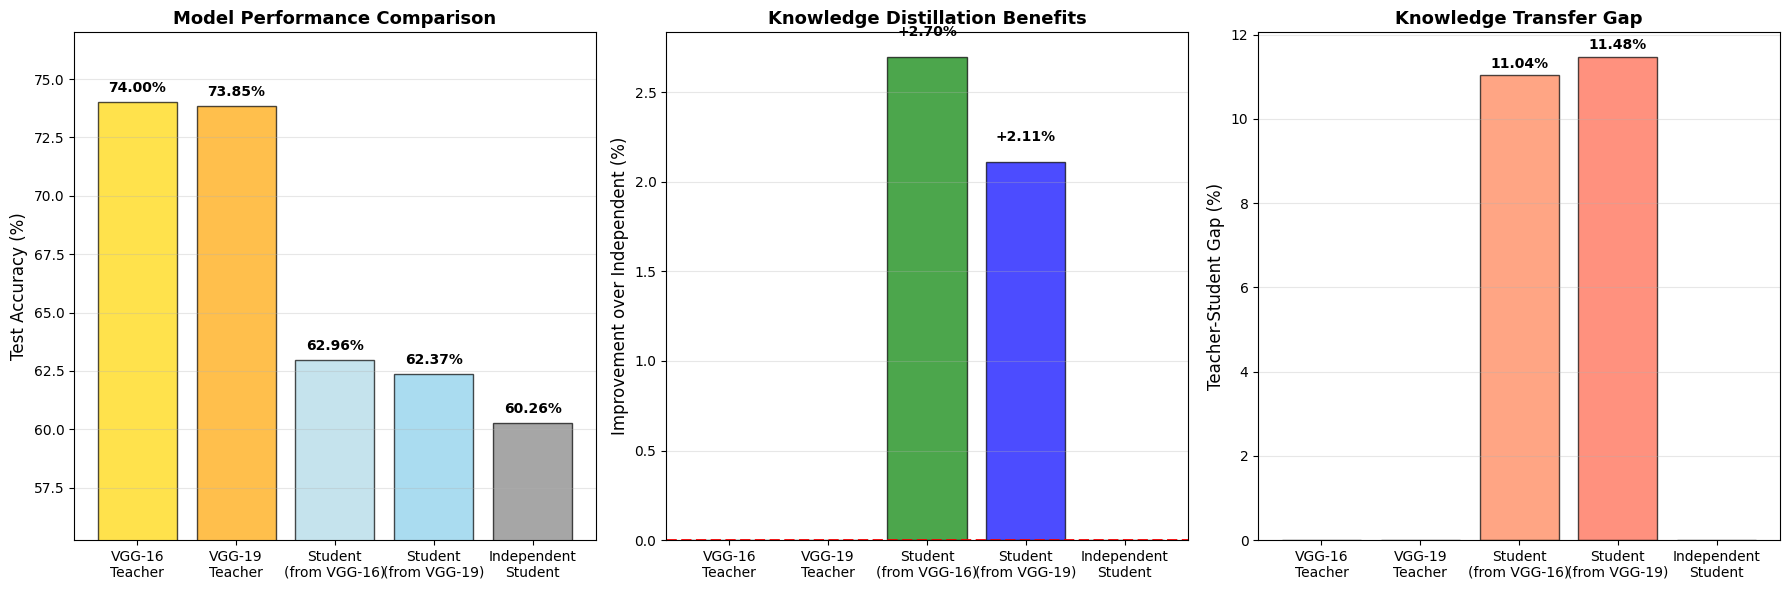

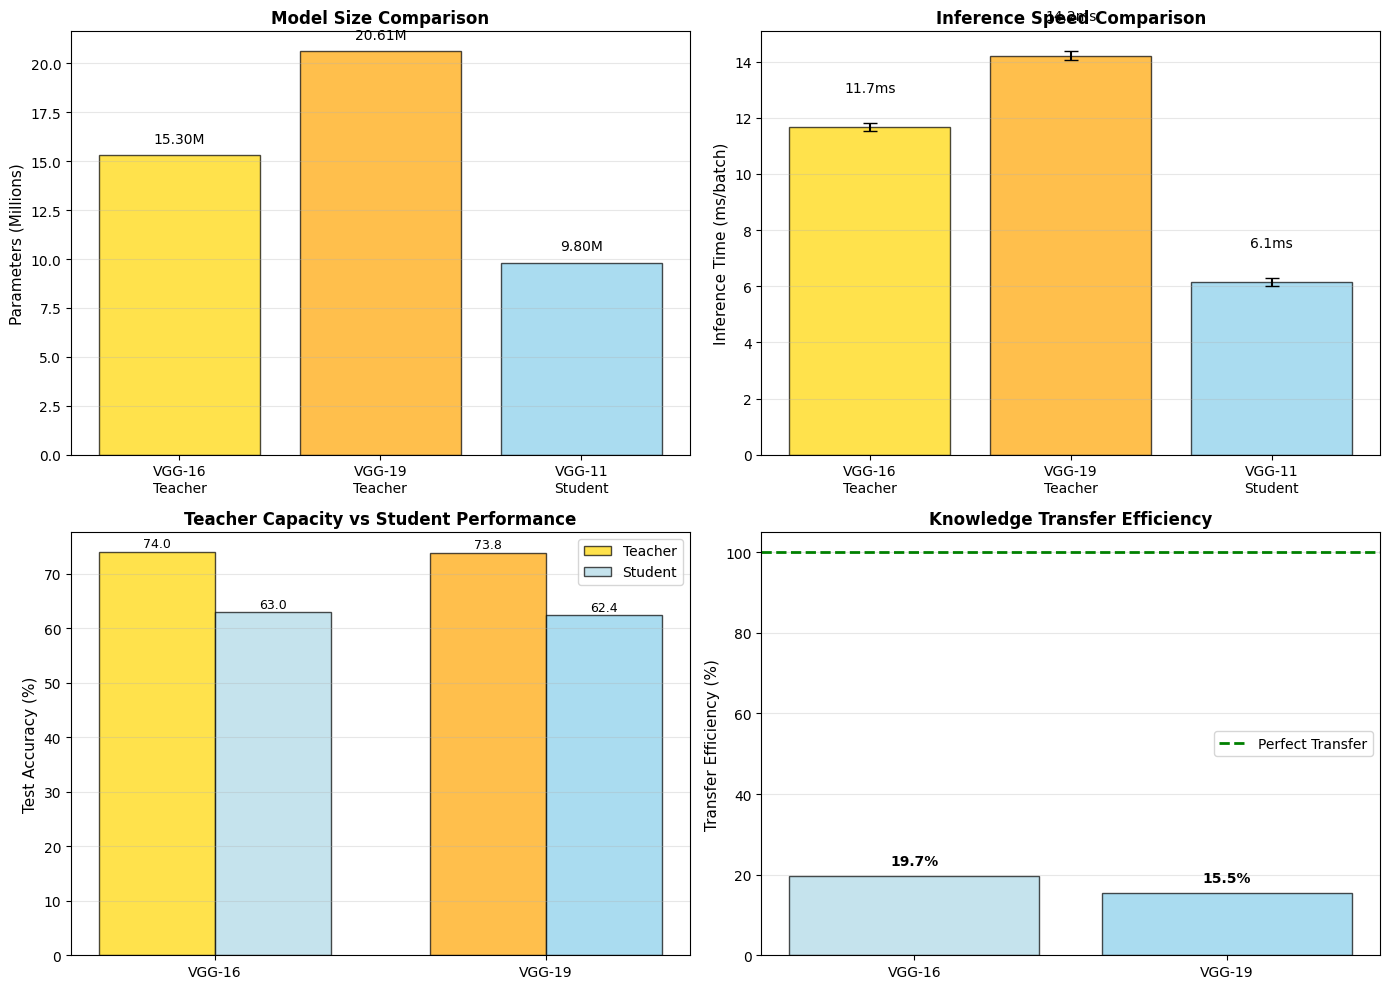

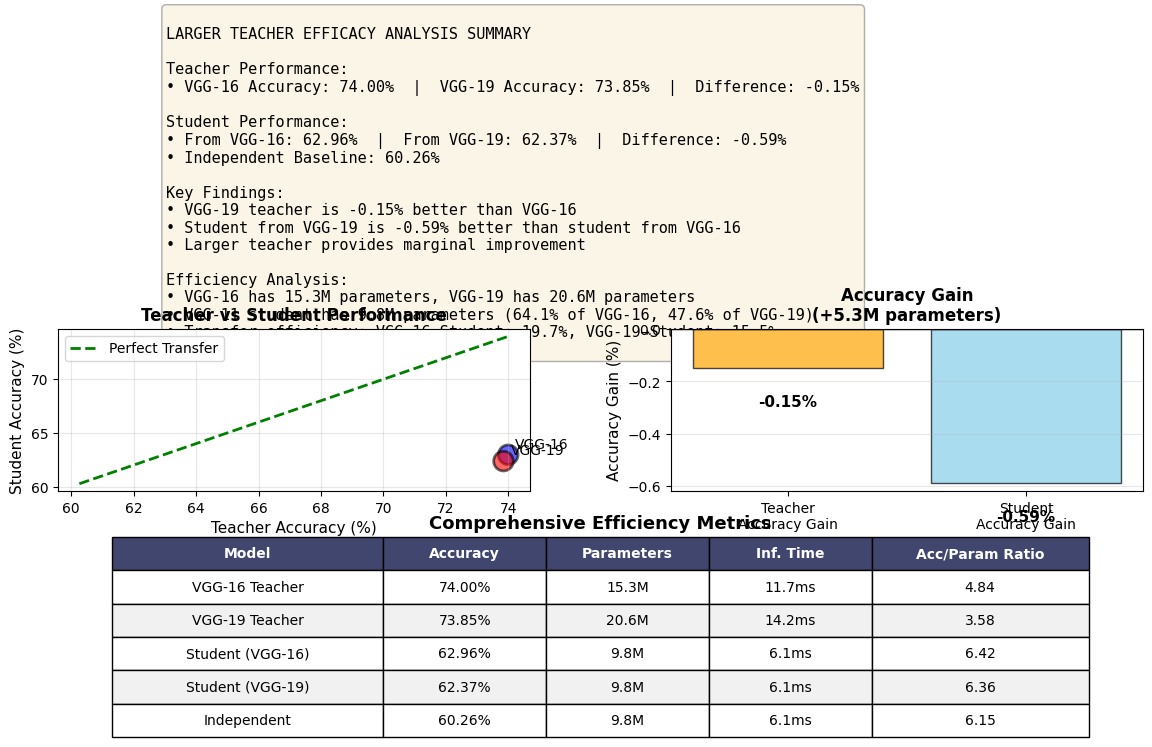

In [122]:
# ==================== VISUALIZATIONS ====================
# 1. Accuracy comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Teachers and Students comparison
models = ['VGG-16\nTeacher', 'VGG-19\nTeacher', 'Student\n(from VGG-16)',
          'Student\n(from VGG-19)', 'Independent\nStudent']
accuracies = [vgg16_acc, vgg19_acc, student_vgg16_acc, student_vgg19_acc, student_indep_acc]
colors = ['gold', 'orange', 'lightblue', 'skyblue', 'gray']

bars = axes[0].bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[0].set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylim([min(accuracies) - 5, max(accuracies) + 3])
axes[0].grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.3,
                f'{acc:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Improvement over independent student
improvements = [0, 0, student_vgg16_acc - student_indep_acc,
                student_vgg19_acc - student_indep_acc, 0]
colors2 = ['gray', 'gray', 'green', 'blue', 'gray']

bars = axes[1].bar(models, improvements, color=colors2, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Improvement over Independent (%)', fontsize=12)
axes[1].set_title('Knowledge Distillation Benefits', fontsize=13, fontweight='bold')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].grid(axis='y', alpha=0.3)

for bar, imp in zip(bars, improvements):
    if imp != 0:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{imp:+.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: Teacher-Student gap
teacher_student_gaps = [0, 0, gap_vgg16, gap_vgg19, 0]
colors3 = ['gray', 'gray', 'coral', 'tomato', 'gray']

bars = axes[2].bar(models, teacher_student_gaps, color=colors3, alpha=0.7, edgecolor='black')
axes[2].set_ylabel('Teacher-Student Gap (%)', fontsize=12)
axes[2].set_title('Knowledge Transfer Gap', fontsize=13, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

for bar, gap in zip(bars, teacher_student_gaps):
    if gap != 0:
        height = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{gap:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('task3_6_teacher_size_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Detailed metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Parameters comparison
models_compact = ['VGG-16\nTeacher', 'VGG-19\nTeacher', 'VGG-11\nStudent']
params = [vgg16_params/1e6, vgg19_params/1e6, student_params/1e6]

axes[0, 0].bar(models_compact, params, color=['gold', 'orange', 'skyblue'], alpha=0.7, edgecolor='black')
axes[0, 0].set_ylabel('Parameters (Millions)', fontsize=11)
axes[0, 0].set_title('Model Size Comparison', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

for i, (model, param) in enumerate(zip(models_compact, params)):
    axes[0, 0].text(i, param + 0.5, f'{param:.2f}M', ha='center', va='bottom', fontsize=10)

# Inference time comparison
times = [vgg16_time*1000, vgg19_time*1000, student_vgg16_time*1000]
stds = [vgg16_std*1000, vgg19_std*1000, student_vgg16_std*1000]

axes[0, 1].bar(models_compact, times, yerr=stds, color=['gold', 'orange', 'skyblue'],
               alpha=0.7, edgecolor='black', capsize=5)
axes[0, 1].set_ylabel('Inference Time (ms/batch)', fontsize=11)
axes[0, 1].set_title('Inference Speed Comparison', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

for i, (model, time_val) in enumerate(zip(models_compact, times)):
    axes[0, 1].text(i, time_val + stds[i] + 1, f'{time_val:.1f}ms', ha='center', va='bottom', fontsize=10)

# Teacher capacity vs Student performance
teacher_accs = [vgg16_acc, vgg19_acc]
student_accs = [student_vgg16_acc, student_vgg19_acc]

x_pos = np.arange(2)
width = 0.35

bars1 = axes[1, 0].bar(x_pos - width/2, teacher_accs, width, label='Teacher',
                       color=['gold', 'orange'], alpha=0.7, edgecolor='black')
bars2 = axes[1, 0].bar(x_pos + width/2, student_accs, width, label='Student',
                       color=['lightblue', 'skyblue'], alpha=0.7, edgecolor='black')

axes[1, 0].set_ylabel('Test Accuracy (%)', fontsize=11)
axes[1, 0].set_title('Teacher Capacity vs Student Performance', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(['VGG-16', 'VGG-19'])
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.3,
                       f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# Transfer efficiency
teacher_labels = ['VGG-16', 'VGG-19']
efficiencies = [transfer_efficiency_vgg16, transfer_efficiency_vgg19]

bars = axes[1, 1].bar(teacher_labels, efficiencies, color=['lightblue', 'skyblue'],
                      alpha=0.7, edgecolor='black')
axes[1, 1].set_ylabel('Transfer Efficiency (%)', fontsize=11)
axes[1, 1].set_title('Knowledge Transfer Efficiency', fontsize=12, fontweight='bold')
axes[1, 1].axhline(y=100, color='green', linestyle='--', linewidth=2, label='Perfect Transfer')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].legend()

for bar, eff in zip(bars, efficiencies):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 2,
                   f'{eff:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('task3_6_detailed_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Analysis summary visualization
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)

# Summary statistics
ax1 = fig.add_subplot(gs[0, :])
ax1.axis('off')

summary_text = f"""
LARGER TEACHER EFFICACY ANALYSIS SUMMARY

Teacher Performance:
• VGG-16 Accuracy: {vgg16_acc:.2f}%  |  VGG-19 Accuracy: {vgg19_acc:.2f}%  |  Difference: {vgg19_acc - vgg16_acc:+.2f}%

Student Performance:
• From VGG-16: {student_vgg16_acc:.2f}%  |  From VGG-19: {student_vgg19_acc:.2f}%  |  Difference: {student_vgg19_acc - student_vgg16_acc:+.2f}%
• Independent Baseline: {student_indep_acc:.2f}%

Key Findings:
• VGG-19 teacher is {vgg19_acc - vgg16_acc:.2f}% better than VGG-16
• Student from VGG-19 is {student_vgg19_acc - student_vgg16_acc:.2f}% better than student from VGG-16
• {'Larger teacher provides marginal improvement' if abs(student_vgg19_acc - student_vgg16_acc) < 1 else 'Larger teacher provides significant improvement'}

Efficiency Analysis:
• VGG-16 has {vgg16_params/1e6:.1f}M parameters, VGG-19 has {vgg19_params/1e6:.1f}M parameters
• VGG-11 student has {student_params/1e6:.1f}M parameters ({student_params/vgg16_params*100:.1f}% of VGG-16, {student_params/vgg19_params*100:.1f}% of VGG-19)
• Transfer efficiency: VGG-16→Student: {transfer_efficiency_vgg16:.1f}%, VGG-19→Student: {transfer_efficiency_vgg19:.1f}%
"""

ax1.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# Scatter plot: Teacher accuracy vs Student accuracy
ax2 = fig.add_subplot(gs[1, 0])
teacher_x = [vgg16_acc, vgg19_acc]
student_y = [student_vgg16_acc, student_vgg19_acc]

ax2.scatter(teacher_x, student_y, s=200, c=['blue', 'red'], alpha=0.6, edgecolors='black', linewidths=2)
ax2.plot([student_indep_acc, max(teacher_x)], [student_indep_acc, max(teacher_x)],
         'g--', linewidth=2, label='Perfect Transfer')
ax2.set_xlabel('Teacher Accuracy (%)', fontsize=11)
ax2.set_ylabel('Student Accuracy (%)', fontsize=11)
ax2.set_title('Teacher vs Student Performance', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

for i, (tx, ty) in enumerate(zip(teacher_x, student_y)):
    label = 'VGG-16' if i == 0 else 'VGG-19'
    ax2.annotate(label, (tx, ty), xytext=(5, 5), textcoords='offset points', fontsize=10)

# Bar chart: Gain per parameter increase
ax3 = fig.add_subplot(gs[1, 1])
param_increase = (vgg19_params - vgg16_params) / 1e6
acc_increase_teacher = vgg19_acc - vgg16_acc
acc_increase_student = student_vgg19_acc - student_vgg16_acc

categories = ['Teacher\nAccuracy Gain', 'Student\nAccuracy Gain']
gains = [acc_increase_teacher, acc_increase_student]
colors_gain = ['orange', 'skyblue']

bars = ax3.bar(categories, gains, color=colors_gain, alpha=0.7, edgecolor='black')
ax3.set_ylabel('Accuracy Gain (%)', fontsize=11)
ax3.set_title(f'Accuracy Gain\n(+{param_increase:.1f}M parameters)', fontsize=12, fontweight='bold')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax3.grid(axis='y', alpha=0.3)

for bar, gain in zip(bars, gains):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.05 if height > 0 else height - 0.1,
            f'{gain:+.2f}%', ha='center', va='bottom' if height > 0 else 'top',
            fontsize=11, fontweight='bold')

# Efficiency metrics
ax4 = fig.add_subplot(gs[2, :])
metrics_data = [
    ['Model', 'Accuracy', 'Parameters', 'Inf. Time', 'Acc/Param Ratio'],
    ['VGG-16 Teacher', f'{vgg16_acc:.2f}%', f'{vgg16_params/1e6:.1f}M', f'{vgg16_time*1000:.1f}ms', f'{vgg16_acc/(vgg16_params/1e6):.2f}'],
    ['VGG-19 Teacher', f'{vgg19_acc:.2f}%', f'{vgg19_params/1e6:.1f}M', f'{vgg19_time*1000:.1f}ms', f'{vgg19_acc/(vgg19_params/1e6):.2f}'],
    ['Student (VGG-16)', f'{student_vgg16_acc:.2f}%', f'{student_params/1e6:.1f}M', f'{student_vgg16_time*1000:.1f}ms', f'{student_vgg16_acc/(student_params/1e6):.2f}'],
    ['Student (VGG-19)', f'{student_vgg19_acc:.2f}%', f'{student_params/1e6:.1f}M', f'{student_vgg19_time*1000:.1f}ms', f'{student_vgg19_acc/(student_params/1e6):.2f}'],
    ['Independent', f'{student_indep_acc:.2f}%', f'{student_params/1e6:.1f}M', f'{student_indep_time*1000:.1f}ms', f'{student_indep_acc/(student_params/1e6):.2f}']
]

table = ax4.table(cellText=metrics_data, cellLoc='center', loc='center',
                  colWidths=[0.25, 0.15, 0.15, 0.15, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(5):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, 6):
    color = '#f1f1f2' if i % 2 == 0 else 'white'
    for j in range(5):
        table[(i, j)].set_facecolor(color)

ax4.axis('off')
ax4.set_title('Comprehensive Efficiency Metrics', fontsize=13, fontweight='bold', pad=20)

plt.savefig('task3_6_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [123]:
# ==================== SAVE RESULTS ====================
results = {
    'teachers': {
        'vgg16': {'accuracy': vgg16_acc, 'parameters': vgg16_params, 'inference_time': vgg16_time},
        'vgg19': {'accuracy': vgg19_acc, 'parameters': vgg19_params, 'inference_time': vgg19_time}
    },
    'students': {
        'from_vgg16': {'accuracy': student_vgg16_acc, 'parameters': student_params, 'inference_time': student_vgg16_time},
        'from_vgg19': {'accuracy': student_vgg19_acc, 'parameters': student_params, 'inference_time': student_vgg19_time},
        'independent': {'accuracy': student_indep_acc, 'parameters': student_params, 'inference_time': student_indep_time}
    },
    'analysis': {
        'teacher_diff': vgg19_acc - vgg16_acc,
        'student_diff': student_vgg19_acc - student_vgg16_acc,
        'vgg16_gap': gap_vgg16,
        'vgg19_gap': gap_vgg19,
        'vgg16_efficiency': transfer_efficiency_vgg16,
        'vgg19_efficiency': transfer_efficiency_vgg19
    }
}

np.save('task3_6_larger_teacher_results.npy', results)
print("\n" + "="*50)
print("Results saved to task3_6_larger_teacher_results.npy")
print("Visualizations saved as PNG files")
print("="*50)


Results saved to task3_6_larger_teacher_results.npy
Visualizations saved as PNG files


In [124]:
import os
import zipfile

# Define paths
base_dir = "/kaggle/working" 
zip_path = os.path.join(base_dir, "all_outputs.zip")

# Create ZIP file excluding 'data' directory
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(base_dir):
        # Skip 'data' directory and anything inside it
        if 'data' in root.split(os.sep):
            continue

        for file in files:
            file_path = os.path.join(root, file)
            # Exclude the zip file itself if re-run
            if file_path == zip_path:
                continue

            arcname = os.path.relpath(file_path, base_dir)
            zipf.write(file_path, arcname)

print(f"✅ Created zip file at: {zip_path}")


✅ Created zip file at: /kaggle/working/all_outputs.zip
